# Evaluación de generalización — Fase 2 (con peatón)

Evaluación del modelo **E2.1** en almacenes no vistos (WH02-05), con un peatón dinámico presente (`ped_obs=True`), comparando **STH-WP** vs **SUB-WP**.

**Protocolo:** 3 seeds × 4 almacenes × 2 métodos × todos los goals × **10 repeticiones por goal** (el peatón se aleatoriza de verdad en cada `reset()`, así que cada repetición es un episodio genuinamente distinto — a diferencia de la fase 1). Volumen total previsto: **81.360 episodios**.

**Corrección de protocolo aplicada:** los mundos de evaluación se dejaron inicialmente con 2 peatones físicos por almacén, lo que producía colisión casi segura (0% de éxito) porque el modelo **solo fue validado con 1 peatón** (baseline real WH01: 88.75% STH-WP / 82.36% SUB-WP, un único peatón en un pasillo corto). Corregido a 1 peatón por almacén — confirmado con test de aislamiento (WH02 seed 42: 0% con 2 peatones → 95% con 1).

> **Nota:** esta evaluación puede estar todavía en curso. Esta celda de carga solo usa los CSV que existan en el momento de ejecutar el notebook — vuelve a ejecutar el notebook completo para refrescar el análisis según avance.

In [1]:
import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 150, "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "grid.color": "#D9D9D9", "grid.linestyle": "--", "grid.alpha": 0.55,
})
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)

BASE           = Path("/Users/adrigarcia/tfm-robots-rl")
RESULTS_DIR    = BASE / "almacenes" / "resultados_evaluacion"
STHWP_DIR      = BASE / "simulacion" / "controllers" / "rl_train_STHWP"
SUBWP_DIR      = BASE / "simulacion" / "controllers" / "rl_train_SUB_WP_continuo"
BASELINE_DIR_S = STHWP_DIR / "experimentos" / "resultados"
BASELINE_DIR_W = SUBWP_DIR / "experimentos" / "resultados"

RESULTADO_ORDEN = ["exito", "col_approach", "col_exit", "col_return", "truncado"]
RESULTADO_COLOR = {
    "exito":        "#2ca02c",
    "col_approach": "#d62728",
    "col_exit":     "#ff7f0e",
    "col_return":   "#9467bd",
    "truncado":     "#7f7f7f",
}
METODO_ORDEN = ["sthwp", "subwp"]
METODO_LABEL = {"sthwp": "STH-WP", "subwp": "SUB-WP"}
METODO_COLOR = {"sthwp": "#1F77B4", "subwp": "#FF7F0E"}
sns.set_palette([METODO_COLOR[m] for m in METODO_ORDEN])
WH_ORDEN     = ["02", "03", "04", "05"]
SEEDS        = ["42", "123", "524"]
N_REPS_ESPERADAS = 10

IMG_DIR = BASE / "almacenes" / "imagenes_evaluacion" / "fase2_con_peaton"
IMG_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    fig.savefig(IMG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")



## 1. Estado de la evaluación
Qué combinaciones almacén × método × seed existen ya, y cuántos episodios tiene cada una respecto a lo esperado (nº de goals × 10 reps).

In [2]:
def n_goals_por_almacen():
    out = {}
    for wh in WH_ORDEN:
        with open(STHWP_DIR / f"warehouse_map{wh}.json") as f:
            mapa = json.load(f)
        out[wh] = len(mapa["shelves"])
    return out

GOALS_POR_WH = n_goals_por_almacen()

filas_estado = []
for metodo in METODO_ORDEN:
    for wh in WH_ORDEN:
        for seed in SEEDS:
            fn = RESULTS_DIR / f"{metodo}_ped_wh{wh}_s{seed}.csv"
            esperado = GOALS_POR_WH[wh] * N_REPS_ESPERADAS
            if fn.exists():
                n = sum(1 for _ in open(fn)) - 1
            else:
                n = 0
            filas_estado.append({
                "metodo": metodo, "warehouse_id": wh, "seed": seed,
                "episodios": n, "esperados": esperado,
                "%completado": round(100 * n / esperado, 1) if esperado else 0,
            })

estado = pd.DataFrame(filas_estado)
estado_pivot = estado.pivot_table(index=["metodo", "warehouse_id"], columns="seed", values="%completado")
estado_pivot


seed                   123     42    524
metodo warehouse_id                     
sthwp  02            100.0  100.0  100.0
       03            100.0  100.0  100.0
       04            100.0  100.0  100.0
       05            100.0  100.0  100.0
subwp  02            100.0  100.0  100.0
       03            100.0  100.0  100.0
       04            100.0  100.0  100.0
       05            100.0  100.0  100.0

In [3]:
print(f"Progreso global: {estado['episodios'].sum()} / {estado['esperados'].sum()} episodios "
      f"({100*estado['episodios'].sum()/estado['esperados'].sum():.1f}%)")


Progreso global: 81360 / 81360 episodios (100.0%)


## 2. Carga de datos disponibles

In [4]:
def cargar_fase2():
    frames = []
    for fn in sorted(glob.glob(str(RESULTS_DIR / "*_ped_wh*_s*.csv"))):
        if "OBSOLETO" in fn:
            continue
        df = pd.read_csv(fn)
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    df["warehouse_id"] = df["warehouse_id"].astype(str).str.zfill(2)
    df["seed"] = df["seed"].astype(str)
    df["exito_bool"] = df["resultado"] == "exito"
    df["resultado"] = pd.Categorical(df["resultado"], categories=RESULTADO_ORDEN, ordered=True)
    df["metodo"] = pd.Categorical(df["metodo"], categories=METODO_ORDEN, ordered=True)
    return df

df2 = cargar_fase2()
print(f"Total episodios cargados: {len(df2)}")
df2.head()


Total episodios cargados: 81360


,episodio,goal_id,rep,resultado,pasos,reward,warehouse_id,metodo,seed,peaton,exito_bool
0,1,goal_001,1,exito,5808,1011.85,02,sthwp,123,1,True
1,2,goal_001,2,exito,5771,1019.87,02,sthwp,123,1,True
2,3,goal_001,3,exito,5770,977.12,02,sthwp,123,1,True
3,4,goal_001,4,exito,5771,1020.57,02,sthwp,123,1,True
4,5,goal_001,5,exito,5770,1020.14,02,sthwp,123,1,True


## 3. Resumen global

In [5]:
resumen_global2 = (
    df2.groupby("metodo", observed=True)["exito_bool"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "tasa_exito", "count": "n_episodios"})
)
resumen_global2["tasa_exito_%"] = (resumen_global2["tasa_exito"] * 100).round(2)
resumen_global2 = resumen_global2.rename(index=METODO_LABEL)
resumen_global2[["n_episodios", "tasa_exito_%"]]


,n_episodios,tasa_exito_%
metodo,,
STH-WP,40680,83.97
SUB-WP,40680,84.32


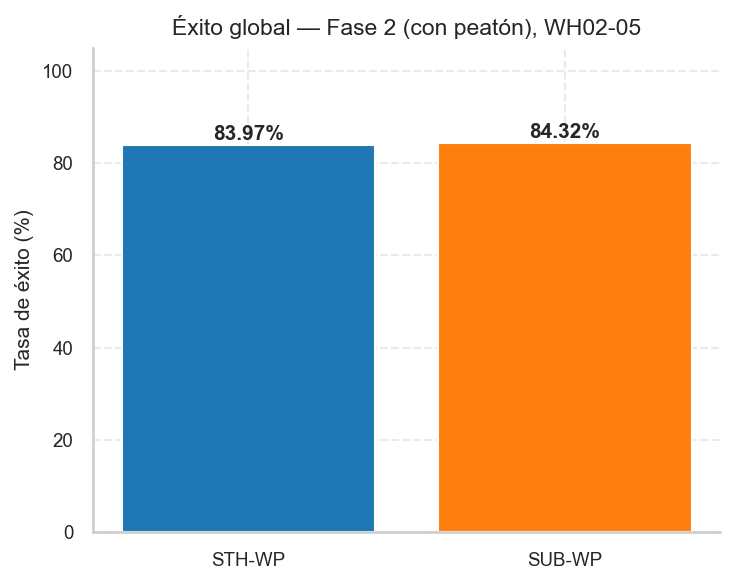

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
vals = resumen_global2["tasa_exito_%"]
bars = ax.bar(vals.index, vals.values, color=["#1f77b4", "#ff7f0e"])
ax.set_ylabel("Tasa de éxito (%)")
ax.set_ylim(0, 105)
ax.set_title("Éxito global — Fase 2 (con peatón), WH02-05")
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")
plt.tight_layout()
guardar(fig, "01_exito_global")
plt.show()


## 4. Resultados por almacén

In [7]:
pivot_wh_metodo2 = (
    df2.groupby(["warehouse_id", "metodo"], observed=True)["exito_bool"]
    .mean().mul(100).round(2)
    .unstack("metodo")
    .reindex(WH_ORDEN)
    .rename(columns=METODO_LABEL)
)
pivot_wh_metodo2.index = ["WH" + w for w in pivot_wh_metodo2.index]
pivot_wh_metodo2


metodo,STH-WP,SUB-WP
WH02,76.34,78.04
WH03,95.38,95.42
WH04,90.49,90.60
WH05,76.51,76.75


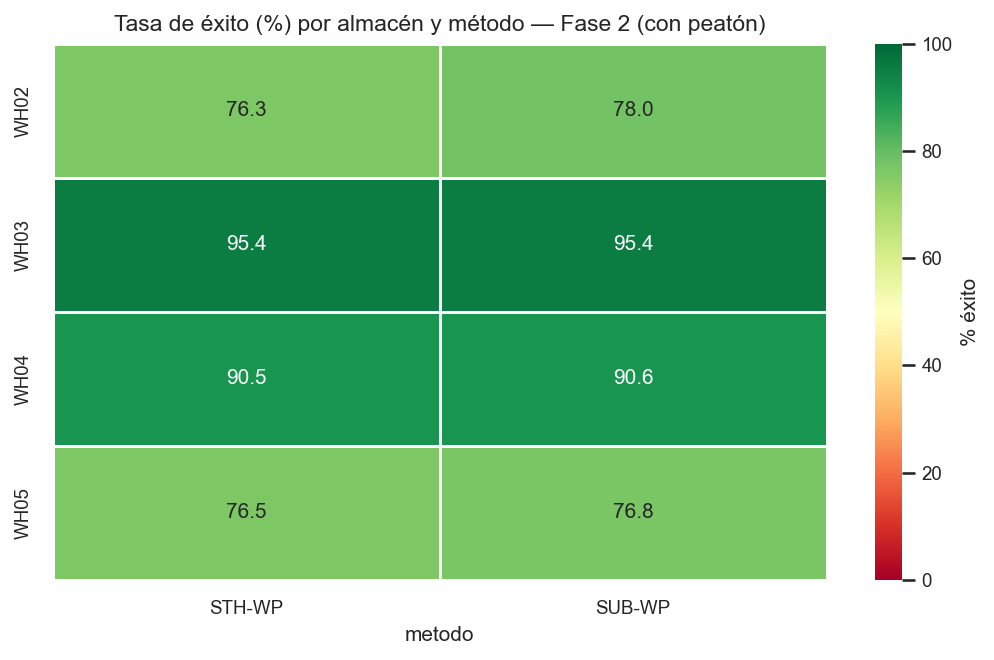

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot_wh_metodo2, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100,
            cbar_kws={"label": "% éxito"}, ax=ax, linewidths=0.5)
ax.set_title("Tasa de éxito (%) por almacén y método — Fase 2 (con peatón)")
plt.tight_layout()
guardar(fig, "02_heatmap_almacen_metodo")
plt.show()


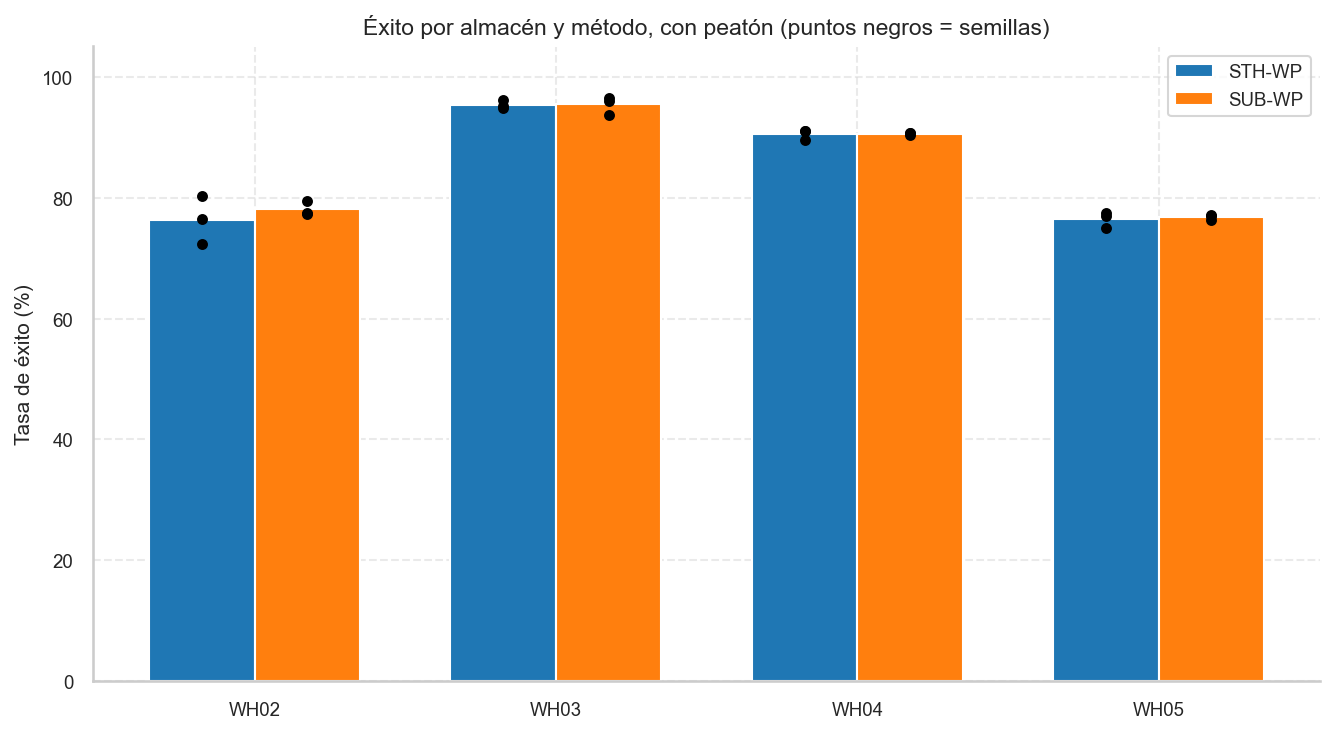

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(WH_ORDEN))
width = 0.35
for i, metodo in enumerate(METODO_ORDEN):
    sub = df2[df2["metodo"] == metodo]
    medias = sub.groupby("warehouse_id", observed=True)["exito_bool"].mean().mul(100).reindex(WH_ORDEN)
    ax.bar(x + (i - 0.5) * width, medias.values, width, label=METODO_LABEL[metodo])
    for seed in SEEDS:
        sub_seed = sub[sub["seed"] == seed]
        if sub_seed.empty:
            continue
        vals = sub_seed.groupby("warehouse_id", observed=True)["exito_bool"].mean().mul(100).reindex(WH_ORDEN)
        ax.scatter(x + (i - 0.5) * width, vals.values, color="black", s=18, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(["WH" + w for w in WH_ORDEN])
ax.set_ylabel("Tasa de éxito (%)")
ax.set_ylim(0, 105)
ax.set_title("Éxito por almacén y método, con peatón (puntos negros = semillas)")
ax.legend()
plt.tight_layout()
guardar(fig, "03_exito_por_almacen_seeds")
plt.show()


### Variabilidad entre seeds


In [10]:
variab_seed2 = (
    df2.groupby(["metodo", "warehouse_id", "seed"], observed=True)["exito_bool"]
    .mean().mul(100).round(2)
    .unstack("seed")
    .reindex(WH_ORDEN, level="warehouse_id")
)
variab_seed2["rango_max_min"] = (variab_seed2.max(axis=1) - variab_seed2.min(axis=1)).round(2)
variab_seed2


seed                   123     42    524  rango_max_min
metodo warehouse_id                                    
sthwp  02            72.33  80.23  76.45           7.90
       03            94.79  95.21  96.15           1.36
       04            90.96  90.96  89.55           1.41
       05            76.99  77.50  75.04           2.46
subwp  02            77.33  79.42  77.38           2.09
       03            96.56  93.75  95.94           2.81
       04            90.76  90.74  90.32           0.44
       05            76.91  77.05  76.28           0.77

## 5. Variabilidad por repetición (peatón aleatorio)
A diferencia de la fase 1, aquí cada una de las 10 repeticiones de un mismo goal es un episodio distinto (posición del peatón aleatorizada). La distribución de la tasa de éxito *por goal* revela si el peatón afecta de forma binaria (el goal siempre falla o siempre tiene éxito, indicando otra causa) o realmente aleatoria (resultado mixto dentro de las 10 repeticiones, es decir, el desenlace depende del cruce puntual con el peatón).

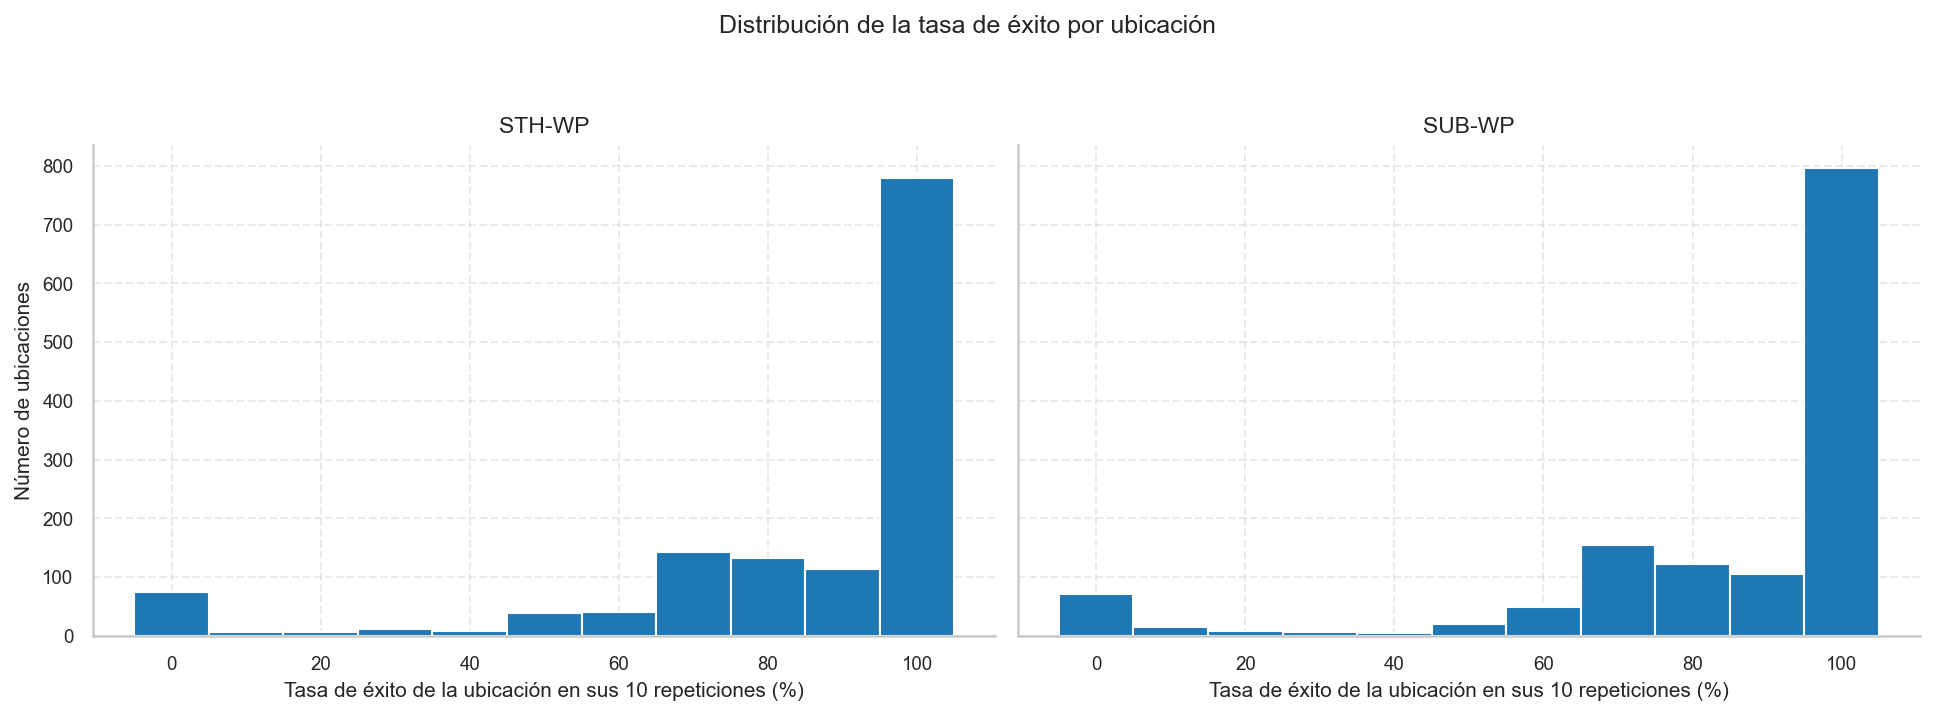

In [11]:
tasa_por_goal = (
    df2.groupby(["metodo", "warehouse_id", "goal_id"], observed=True)["exito_bool"]
    .mean().mul(100)
)

metodos_disponibles = tasa_por_goal.index.get_level_values("metodo").unique()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, metodo in zip(axes, METODO_ORDEN):
    if metodo not in metodos_disponibles:
        ax.set_title(f"{METODO_LABEL[metodo]} (sin datos todavía)")
        continue
    vals = tasa_por_goal.xs(metodo, level="metodo")
    ax.hist(vals.values, bins=11, range=(-5, 105), color="#1f77b4", edgecolor="white")
    ax.set_title(METODO_LABEL[metodo])
    ax.set_xlabel("Tasa de éxito de la ubicación en sus 10 repeticiones (%)")
axes[0].set_ylabel("Número de ubicaciones")
fig.suptitle("Distribución de la tasa de éxito por ubicación", y=1.05)
plt.tight_layout()
guardar(fig, "04_distribucion_tasa_exito_por_goal")
plt.show()


In [12]:
goals_mixtos = tasa_por_goal[(tasa_por_goal > 0) & (tasa_por_goal < 100)].sort_values()
print(f"Goals con resultado mixto (ni 0% ni 100% de éxito en sus repeticiones): {len(goals_mixtos)} / {len(tasa_por_goal)}")
goals_mixtos.to_frame("tasa_exito_%").head(30)


Goals con resultado mixto (ni 0% ni 100% de éxito en sus repeticiones): 1119 / 2712


tasa_exito_%
metodo warehouse_id goal_id               
subwp  02           goal_165      3.333333
                    goal_070      3.333333
       04           goal_144      3.333333
       02           goal_075      3.333333
                    goal_076      3.333333
sthwp  02           goal_164      3.333333
subwp  02           goal_163      3.333333
                    goal_164      3.333333
       04           goal_131      3.333333
sthwp  03           goal_034      3.333333
subwp  04           goal_142      3.333333
       03           goal_034      3.333333
       04           goal_146      3.333333
                    goal_140      3.333333
                    goal_111      3.333333
                    goal_112      3.333333
                    goal_113      3.333333
                    goal_114      3.333333
                    goal_118      3.333333
                    goal_119      3.333333
                    goal_120      3.333333
                    goal_121      3.333333
                    goal_122      3.333333
                    goal_123      3.333333
                    goal_128      3.333333
                    goal_109      3.333333
       02           goal_069      3.333333
       04           goal_133      3.333333
                    goal_151      3.333333
       02           goal_053      3.333333

### Desglose completo de tipos de resultado por goal
Un goal puede tener varios tipos de colisión distintos entre sus repeticiones (no solo éxito/fallo). Aquí se cuentan **todos** los tipos que aparecen para cada goal (sobre sus 30 episodios: 3 seeds × 10 reps), no solo el predominante.

In [13]:
tabla_tipos_por_goal = (
    df2.groupby(["metodo", "warehouse_id", "goal_id", "resultado"], observed=True)
    .size().unstack("resultado", fill_value=0)
    .reindex(columns=RESULTADO_ORDEN, fill_value=0)
)
tabla_tipos_por_goal["n_tipos_distintos"] = (tabla_tipos_por_goal > 0).sum(axis=1)
tabla_tipos_por_goal["n_episodios"] = tabla_tipos_por_goal[RESULTADO_ORDEN].sum(axis=1)

n_mixtos_tipo = (tabla_tipos_por_goal["n_tipos_distintos"] > 1).sum()
print(f"Goals con más de un tipo de resultado distinto entre sus repeticiones: "
      f"{n_mixtos_tipo} / {len(tabla_tipos_por_goal)}")

tabla_tipos_mixtos = (
    tabla_tipos_por_goal[tabla_tipos_por_goal["n_tipos_distintos"] > 1]
    .sort_values(["n_tipos_distintos", "n_episodios"], ascending=[False, False])
)
tabla_tipos_mixtos.head(30)


Goals con más de un tipo de resultado distinto entre sus repeticiones: 1210 / 2712


resultado                     exito  col_approach  col_exit  col_return  truncado  n_tipos_distintos  n_episodios
metodo warehouse_id goal_id                                                                                      
sthwp  02           goal_001     15            10         5           0         0                  3           30
                    goal_002     13            10         7           0         0                  3           30
                    goal_054     13             2        15           0         0                  3           30
                    goal_055     13             1        16           0         0                  3           30
                    goal_056      2            15        13           0         0                  3           30
                    goal_063      5            19         6           0         0                  3           30
                    goal_151      5             9        16           0         0                  3           30
                    goal_152     11            10         9           0         0                  3           30
       03           goal_032     19             7         4           0         0                  3           30
                    goal_033      9            15         6           0         0                  3           30
                    goal_034      1            14        15           0         0                  3           30
       04           goal_105      9             1        20           0         0                  3           30
                    goal_106     10             2        18           0         0                  3           30
                    goal_107      7             8        15           0         0                  3           30
                    goal_108      6             9        15           0         0                  3           30
                    goal_112     10            14         6           0         0                  3           30
                    goal_128      4            21         5           0         0                  3           30
       05           goal_085     14             0        10           6         0                  3           30
                    goal_087     15             0        10           5         0                  3           30
                    goal_105     12             0        10           8         0                  3           30
                    goal_107     18             0         2          10         0                  3           30
                    goal_133     15             0        10           5         0                  3           30
                    goal_155     10             0        10          10         0                  3           30
                    goal_166     26             1         0           3         0                  3           30
                    goal_168     22             4         0           4         0                  3           30
                    goal_170     23             1         0           6         0                  3           30
                    goal_172     23             1         0           6         0                  3           30
                    goal_174     22             2         0           6         0                  3           30
                    goal_176     21             2         0           7         0                  3           30
                    goal_178     17             3         0          10         0                  3           30

Distribución de cuántos goals tienen 1, 2, 3 o 4 tipos de resultado distintos entre sus repeticiones:

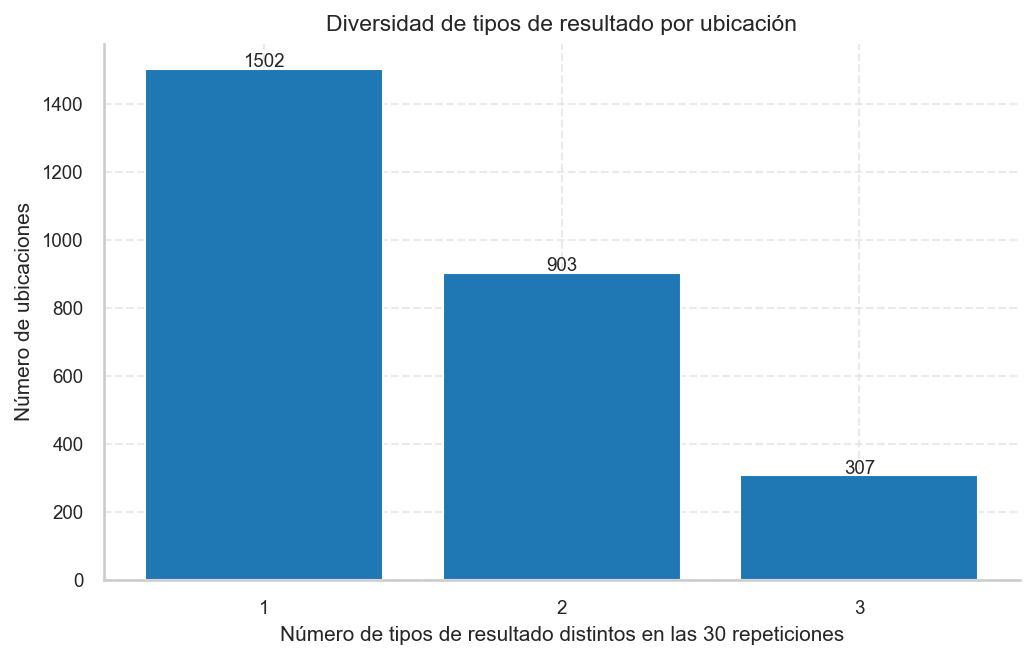

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
conteo_n_tipos = tabla_tipos_por_goal["n_tipos_distintos"].value_counts().sort_index()
bars = ax.bar(conteo_n_tipos.index.astype(str), conteo_n_tipos.values, color="#1f77b4")
for b, v in zip(bars, conteo_n_tipos.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 5, str(v), ha="center", fontsize=9)
ax.set_xlabel("Número de tipos de resultado distintos en las 30 repeticiones")
ax.set_ylabel("Número de ubicaciones")
ax.set_title("Diversidad de tipos de resultado por ubicación")
plt.tight_layout()
guardar(fig, "16_diversidad_tipos_resultado_por_goal")
plt.show()


Composición exacta (de las 30 repeticiones) de los 20 goals con más tipos de resultado distintos y más episodios fallidos — para ver todos los tipos de colisión que sufre cada uno, no solo el predominante:

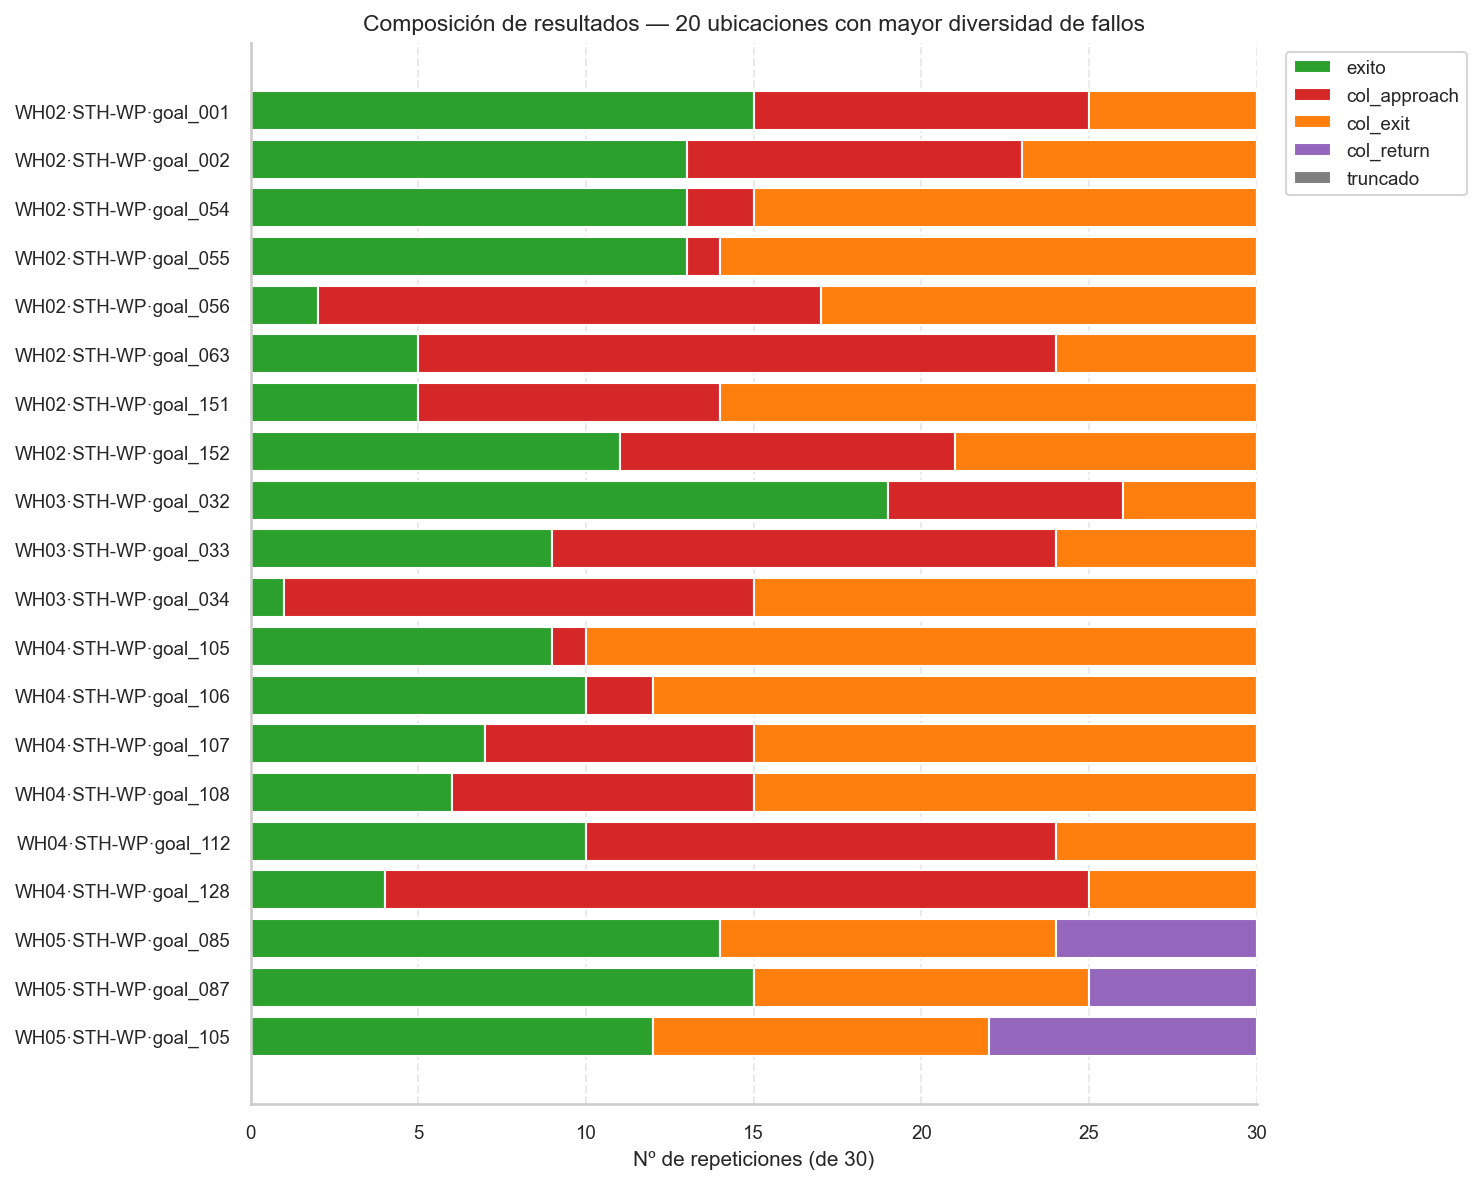

In [15]:
top20 = tabla_tipos_mixtos.head(20)
labels = [f"WH{wh}·{METODO_LABEL[m]}·{g}" for m, wh, g in top20.index]

fig, ax = plt.subplots(figsize=(10, 8))
bottom = np.zeros(len(top20))
for resultado in RESULTADO_ORDEN:
    if resultado not in top20.columns:
        continue
    vals = top20[resultado].values
    ax.barh(labels, vals, left=bottom, label=resultado, color=RESULTADO_COLOR[resultado])
    bottom += vals
ax.set_xlabel("Nº de repeticiones (de 30)")
ax.set_title("Composición de resultados — 20 ubicaciones con mayor diversidad de fallos")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
guardar(fig, "17_composicion_top20_goals_mixtos")
plt.show()


## 6. Coste de la evitación de peatón
Comparación directa fase 1 (sin peatón) vs fase 2 (con peatón) para las mismas combinaciones almacén × método × seed — cuánto cae la tasa de éxito por la sola presencia del peatón.

In [16]:
def cargar_fase1_para_comparar():
    frames = []
    for fn in sorted(glob.glob(str(RESULTS_DIR / "*_wh*_s*.csv"))):
        if "_ped_" in fn:
            continue
        frames.append(pd.read_csv(fn))
    df = pd.concat(frames, ignore_index=True)
    df["warehouse_id"] = df["warehouse_id"].astype(str).str.zfill(2)
    df["seed"] = df["seed"].astype(str)
    df["exito_bool"] = df["resultado"] == "exito"
    return df

df1_ref = cargar_fase1_para_comparar()

exito_f1 = df1_ref.groupby(["metodo", "warehouse_id"])["exito_bool"].mean().mul(100)
exito_f2 = df2.groupby(["metodo", "warehouse_id"], observed=True)["exito_bool"].mean().mul(100)

coste = pd.DataFrame({"fase1_sin_peaton_%": exito_f1, "fase2_con_peaton_%": exito_f2})
coste["coste_pp"] = (coste["fase1_sin_peaton_%"] - coste["fase2_con_peaton_%"]).round(2)
coste = coste.round(2)
coste


fase1_sin_peaton_%  fase2_con_peaton_%  coste_pp
metodo warehouse_id                                                  
sthwp  02                         96.90               76.34     20.56
       03                        100.00               95.38      4.62
       04                         99.78               90.49      9.29
       05                         98.51               76.51     22.00
subwp  02                        100.00               78.04     21.96
       03                        100.00               95.42      4.58
       04                        100.00               90.60      9.40
       05                        100.00               76.75     23.25

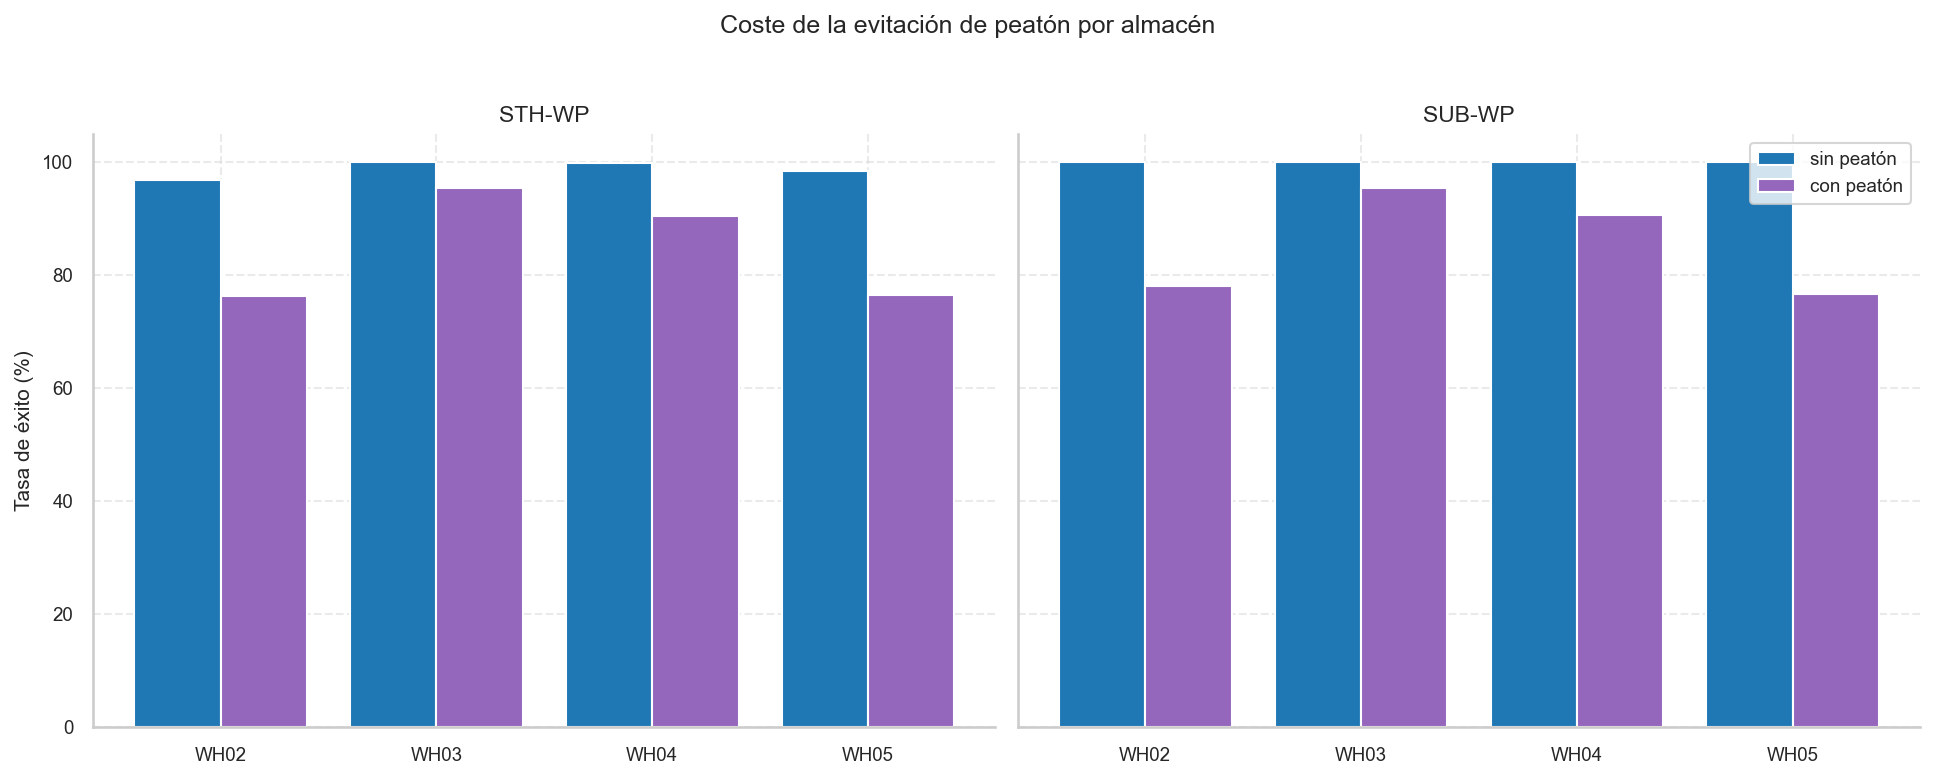

In [17]:
metodos_con_coste = coste.index.get_level_values("metodo").unique()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metodo in zip(axes, METODO_ORDEN):
    if metodo not in metodos_con_coste:
        ax.set_title(f"{METODO_LABEL[metodo]} (sin datos todavía)")
        continue
    sub = coste.xs(metodo, level="metodo").reindex(WH_ORDEN)
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub["fase1_sin_peaton_%"], width=0.4, label="sin peatón", color="#1F77B4")
    ax.bar(x + 0.2, sub["fase2_con_peaton_%"], width=0.4, label="con peatón", color="#9467BD")
    ax.set_xticks(x)
    ax.set_xticklabels(["WH" + w for w in sub.index])
    ax.set_title(METODO_LABEL[metodo])
    ax.set_ylim(0, 105)
axes[0].set_ylabel("Tasa de éxito (%)")
axes[1].legend()
fig.suptitle("Coste de la evitación de peatón por almacén", y=1.03)
plt.tight_layout()
guardar(fig, "05_coste_evitacion_peaton")
plt.show()


### Longitud del pasillo del peatón vs tasa de éxito
Cada punto es un almacén; la longitud del pasillo se lee del `--trajectory` real de `PEDESTRIAN_1` en cada `.wbt` (WH02=26.6m, WH03=8.6m, WH04=57.0m, WH05=60.0m — igual que WH04 pero más colisiones).

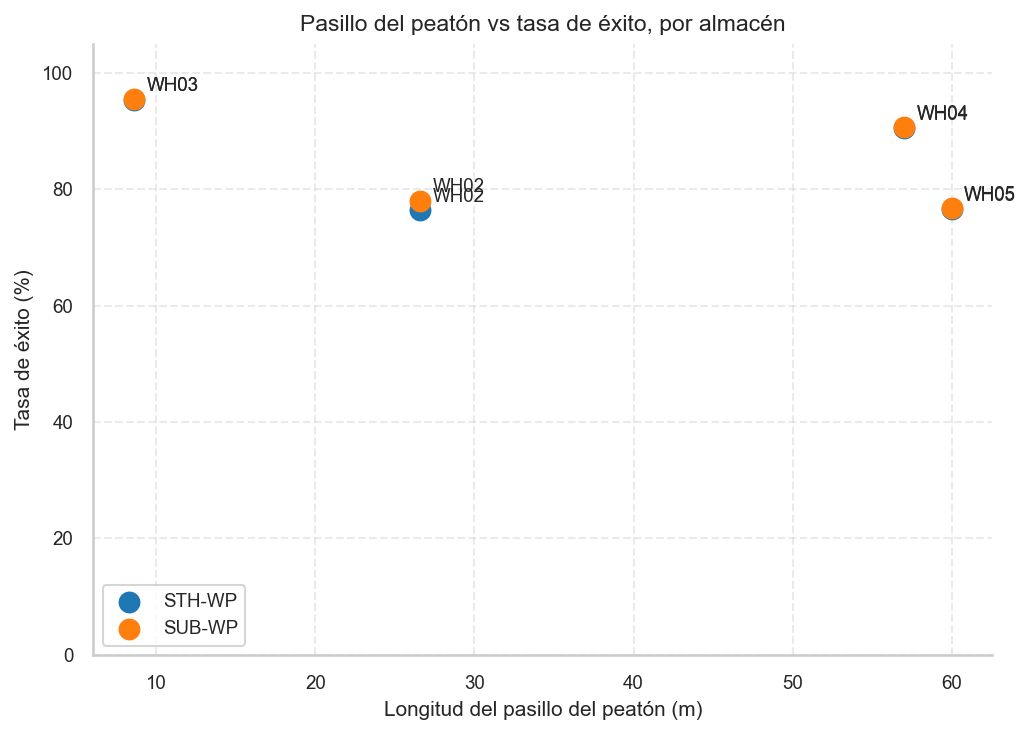

In [18]:
PASILLO_PEATON_M = {"02": 26.6, "03": 8.6, "04": 57.0, "05": 60.0}

fig, ax = plt.subplots(figsize=(7, 5))
for metodo, color in zip(METODO_ORDEN, ["#1f77b4", "#ff7f0e"]):
    xs = [PASILLO_PEATON_M[wh] for wh in WH_ORDEN]
    ys = [pivot_wh_metodo2.loc["WH" + wh, METODO_LABEL[metodo]] for wh in WH_ORDEN]
    ax.scatter(xs, ys, label=METODO_LABEL[metodo], color=color, s=90, zorder=3)
    for wh, x, y in zip(WH_ORDEN, xs, ys):
        ax.annotate(f"WH{wh}", (x, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Longitud del pasillo del peatón (m)")
ax.set_ylabel("Tasa de éxito (%)")
ax.set_ylim(0, 105)
ax.set_title("Pasillo del peatón vs tasa de éxito, por almacén")
ax.legend()
plt.tight_layout()
guardar(fig, "10_pasillo_peaton_vs_exito")
plt.show()


## 7. Comparación con el baseline de entrenamiento (WH01, con peatón)

In [19]:
def cargar_baseline_wh01_ped():
    filas = []
    for metodo, carpeta in [("sthwp", BASELINE_DIR_S), ("subwp", BASELINE_DIR_W)]:
        for fn in sorted(glob.glob(str(carpeta / f"{metodo}_infer_e2_1_s*.csv"))):
            if "noped" in fn:
                continue
            d = pd.read_csv(fn)
            d["metodo"] = metodo
            filas.append(d)
    d = pd.concat(filas, ignore_index=True)
    d["exito_bool"] = d["resultado"] == "exito"
    return d

baseline_wh01_ped = cargar_baseline_wh01_ped()
resumen_wh01_ped = baseline_wh01_ped.groupby("metodo")["exito_bool"].mean().mul(100).round(2)

comparacion_gap2 = pd.DataFrame({
    "WH01 (entrenamiento, 1 peatón)": resumen_wh01_ped,
    "WH02-05 (generalización, media)": df2.groupby("metodo", observed=True)["exito_bool"].mean().mul(100).round(2),
})
comparacion_gap2.index = [METODO_LABEL[m] for m in comparacion_gap2.index]
comparacion_gap2["gap_generalizacion_pp"] = (comparacion_gap2["WH01 (entrenamiento, 1 peatón)"]
                                              - comparacion_gap2["WH02-05 (generalización, media)"]).round(2)
comparacion_gap2


,"WH01 (entrenamiento, 1 peatón)","WH02-05 (generalización, media)",gap_generalizacion_pp
STH-WP,88.75,83.97,4.78
SUB-WP,82.36,84.32,-1.96


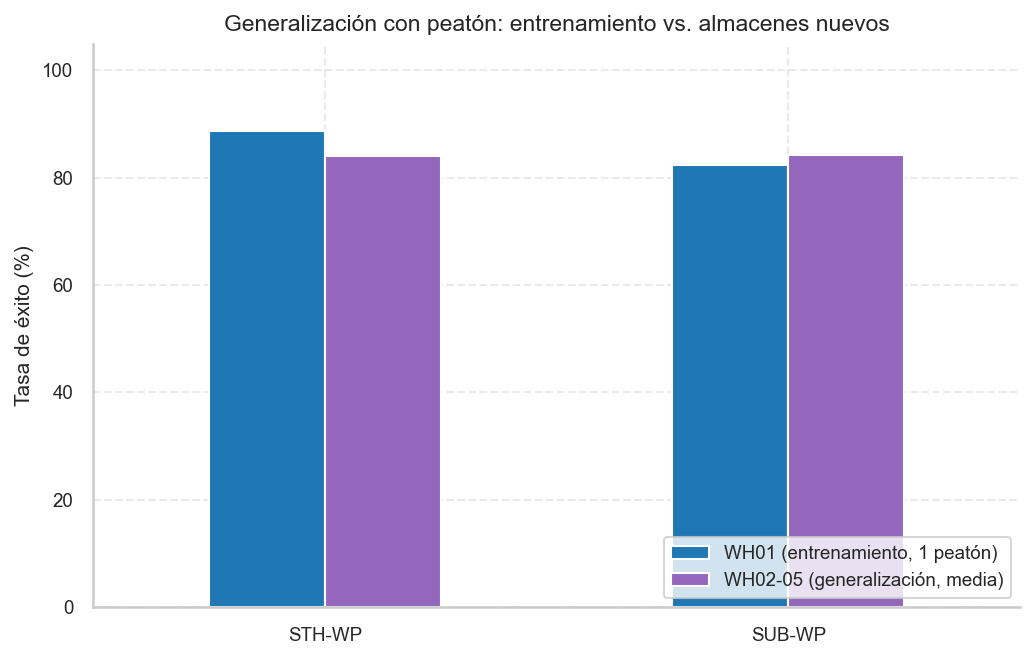

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
comparacion_gap2[["WH01 (entrenamiento, 1 peatón)", "WH02-05 (generalización, media)"]].plot(
    kind="bar", ax=ax, color=["#1F77B4", "#9467BD"], rot=0)
ax.set_ylabel("Tasa de éxito (%)")
ax.set_ylim(0, 105)
ax.set_title("Generalización con peatón: entrenamiento vs. almacenes nuevos")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
guardar(fig, "06_comparacion_baseline_wh01")
plt.show()


## 8. Desglose de fallos

In [21]:
desglose2 = (
    df2.groupby(["warehouse_id", "metodo", "resultado"], observed=False)
    .size().unstack("resultado").fillna(0).astype(int)
    .reindex(WH_ORDEN, level="warehouse_id")
)
desglose2_pct = desglose2.div(desglose2.sum(axis=1), axis=0).mul(100).round(2)
desglose2


resultado            exito  col_approach  col_exit  col_return  truncado
warehouse_id metodo                                                     
02           sthwp    3939           585       636           0         0
             subwp    4027           533       600           0         0
03           sthwp    2747            38        95           0         0
             subwp    2748            61        71           0         0
04           sthwp   16179           649      1052           0         0
             subwp   16200           633      1047           0         0
05           sthwp   11293           278       265        2924         0
             subwp   11328           322        30        3080         0

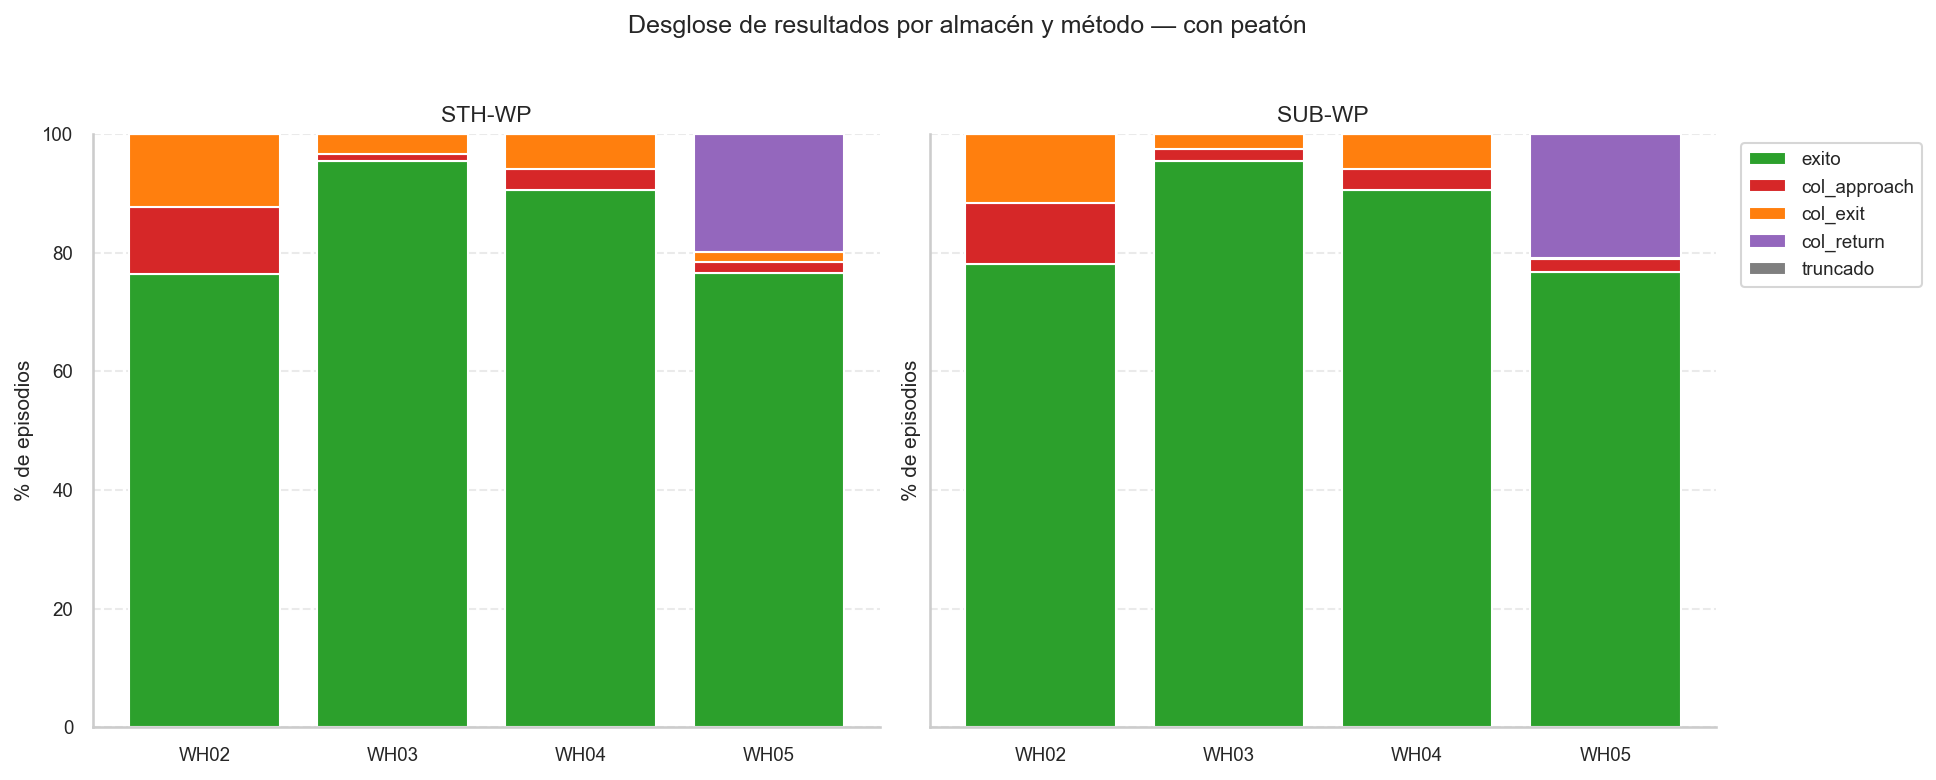

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metodo in zip(axes, METODO_ORDEN):
    if metodo not in desglose2_pct.index.get_level_values("metodo"):
        continue
    sub = desglose2_pct.xs(metodo, level="metodo").reindex(WH_ORDEN)
    bottom = np.zeros(len(sub))
    for resultado in RESULTADO_ORDEN:
        if resultado not in sub.columns:
            continue
        vals = sub[resultado].fillna(0).values
        ax.bar(["WH" + w for w in sub.index], vals, bottom=bottom,
               label=resultado, color=RESULTADO_COLOR[resultado])
        bottom += vals
    ax.set_title(METODO_LABEL[metodo])
    ax.set_ylabel("% de episodios")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Desglose de resultados por almacén y método — con peatón", y=1.03)
plt.tight_layout()
guardar(fig, "07_desglose_fallos")
plt.show()


### Distribución de los tipos de fallo (sin el éxito)
Igual que en fase 1: recalculado solo entre los episodios fallidos de cada almacén/método (suman 100%), para comparar mejor qué tipo de colisión predomina con peatón presente.

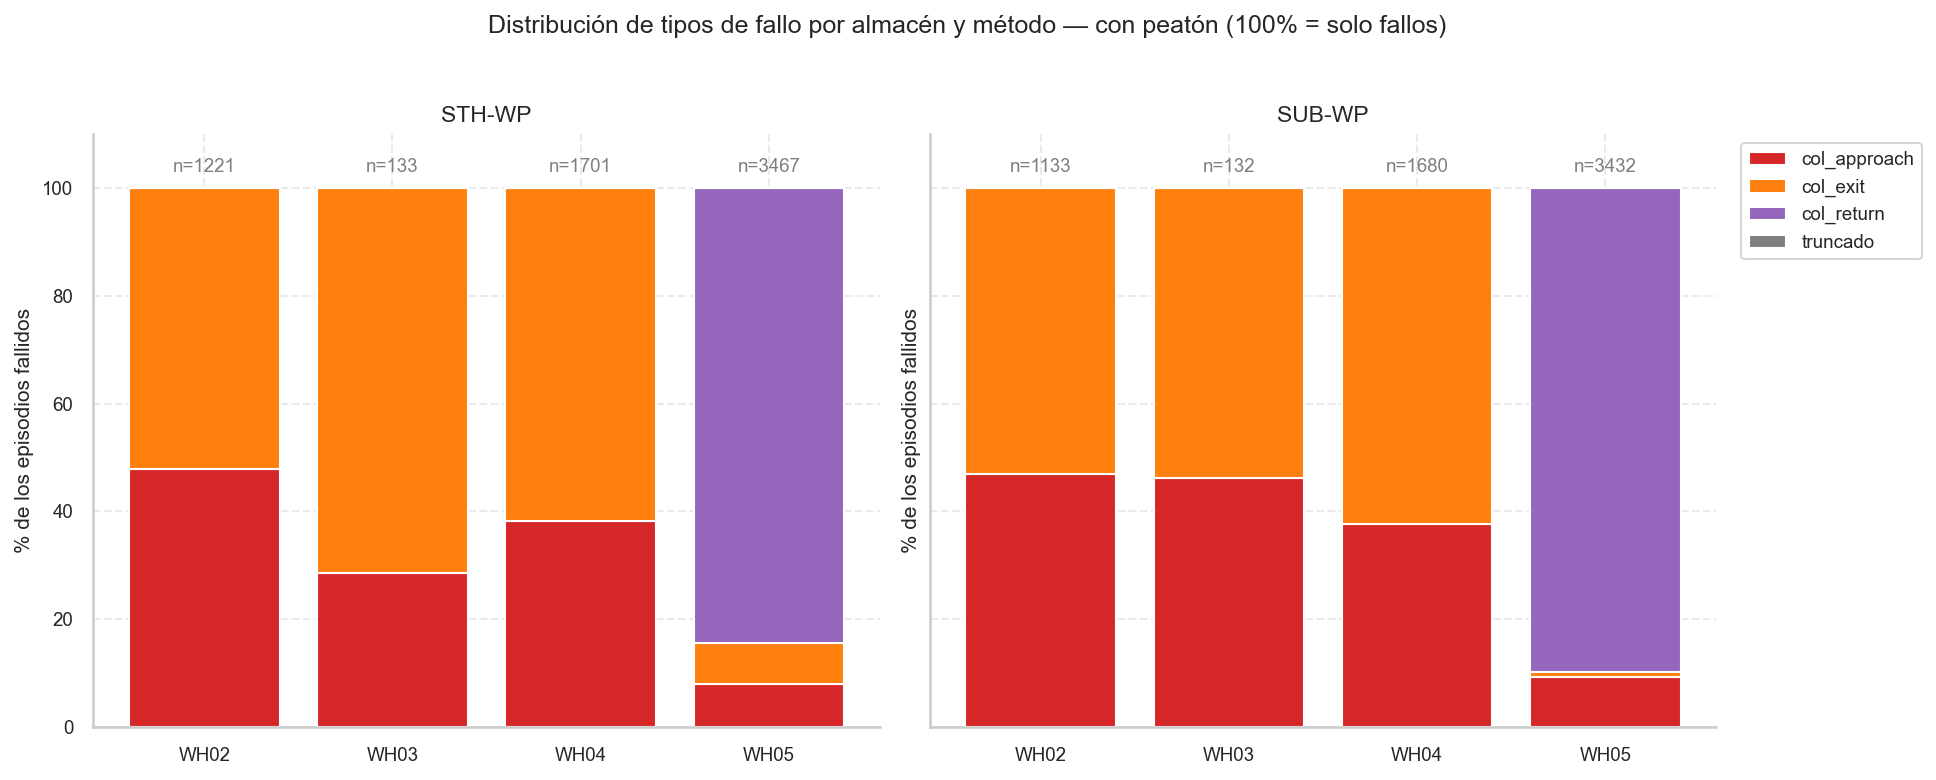

In [23]:
fallo_cols2 = [r for r in RESULTADO_ORDEN if r != "exito" and r in desglose2.columns]
n_fallos_totales2 = desglose2[fallo_cols2].sum(axis=1)
desglose2_fallos_pct = desglose2[fallo_cols2].div(n_fallos_totales2, axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metodo in zip(axes, METODO_ORDEN):
    sub = desglose2_fallos_pct.xs(metodo, level="metodo").reindex(WH_ORDEN)
    n_sub = n_fallos_totales2.xs(metodo, level="metodo").reindex(WH_ORDEN)
    bottom = np.zeros(len(sub))
    for resultado in fallo_cols2:
        vals = sub[resultado].fillna(0).values
        ax.bar(["WH" + w for w in sub.index], vals, bottom=bottom,
               label=resultado, color=RESULTADO_COLOR[resultado])
        bottom += vals
    for x, n in enumerate(n_sub.values):
        ax.text(x, 103, f"n={int(n)}", ha="center", fontsize=9, color="gray")
    ax.set_title(METODO_LABEL[metodo])
    ax.set_ylabel("% de los episodios fallidos")
    ax.set_ylim(0, 110)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Distribución de tipos de fallo por almacén y método — con peatón (100% = solo fallos)", y=1.03)
plt.tight_layout()
guardar(fig, "07b_distribucion_tipos_fallo")
plt.show()


## 9bis. Correlación STH-WP vs SUB-WP por goal
¿Fallan ambos métodos en los mismos goals, o en goals distintos? Cada punto es un goal (tasa de éxito en sus repeticiones para cada método). Sobre la diagonal = SUB-WP mejor en ese goal; bajo la diagonal = STH-WP mejor.

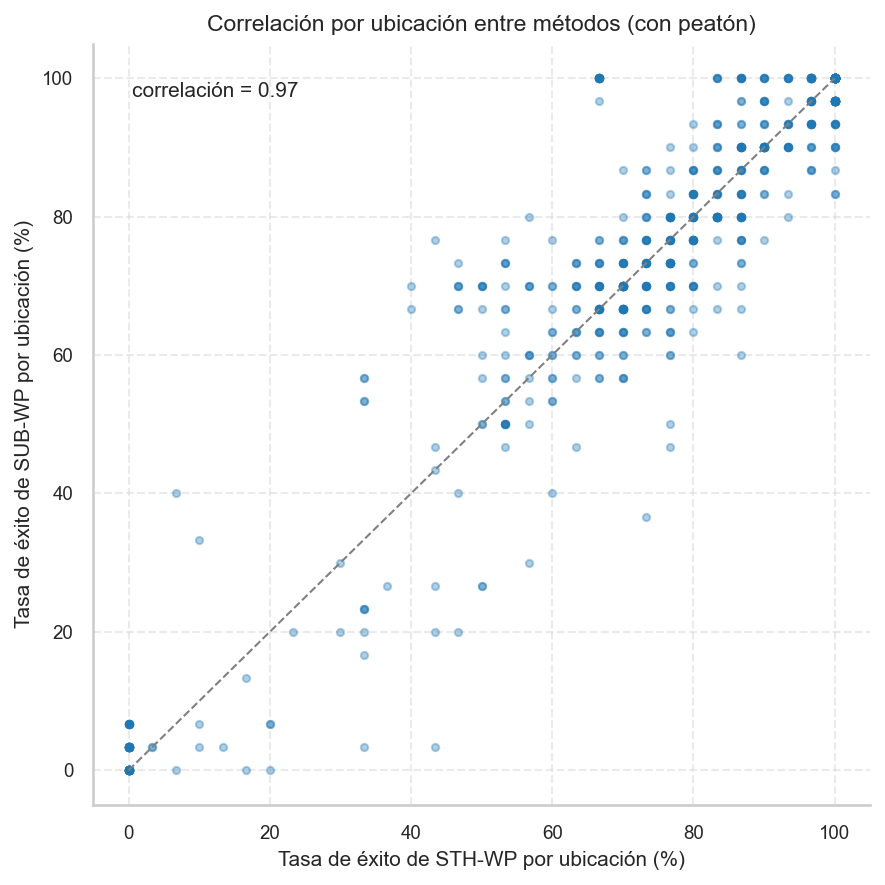

In [24]:
tasa_ancha = tasa_por_goal.unstack("metodo")
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(tasa_ancha["sthwp"], tasa_ancha["subwp"], s=12, alpha=0.35, color="#1f77b4")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Tasa de éxito de STH-WP por ubicación (%)")
ax.set_ylabel("Tasa de éxito de SUB-WP por ubicación (%)")
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)
ax.set_title("Correlación por ubicación entre métodos (con peatón)")
corr = tasa_ancha["sthwp"].corr(tasa_ancha["subwp"])
ax.text(0.05, 0.95, f"correlación = {corr:.2f}", transform=ax.transAxes, va="top")
plt.tight_layout()
guardar(fig, "11_correlacion_sthwp_subwp_por_goal")
plt.show()


## 9. Distribución de pasos y reward

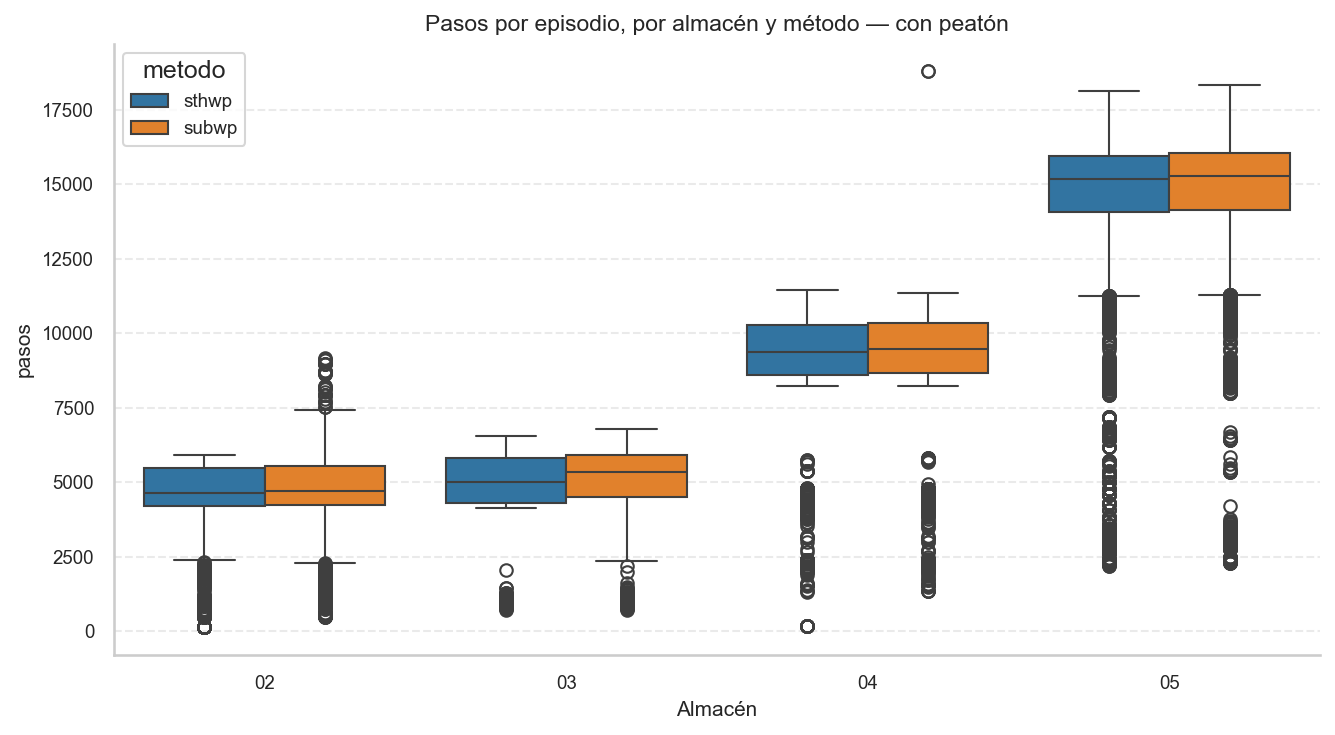

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df2, x="warehouse_id", y="pasos", hue="metodo", order=WH_ORDEN, ax=ax)
ax.set_title("Pasos por episodio, por almacén y método — con peatón")
ax.set_xlabel("Almacén")
plt.tight_layout()
guardar(fig, "08a_pasos_por_almacen")
plt.show()


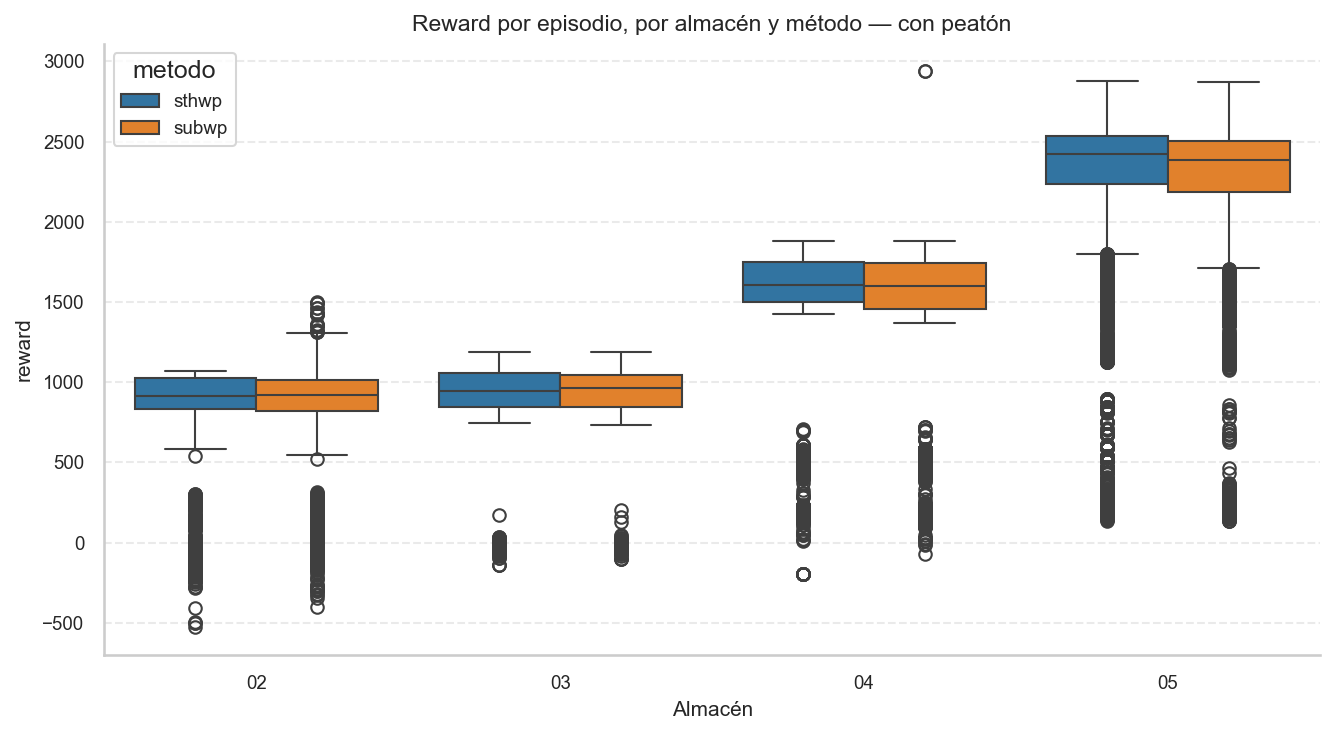

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df2, x="warehouse_id", y="reward", hue="metodo", order=WH_ORDEN, ax=ax)
ax.set_title("Reward por episodio, por almacén y método — con peatón")
ax.set_xlabel("Almacén")
plt.tight_layout()
guardar(fig, "08b_reward_por_almacen")
plt.show()


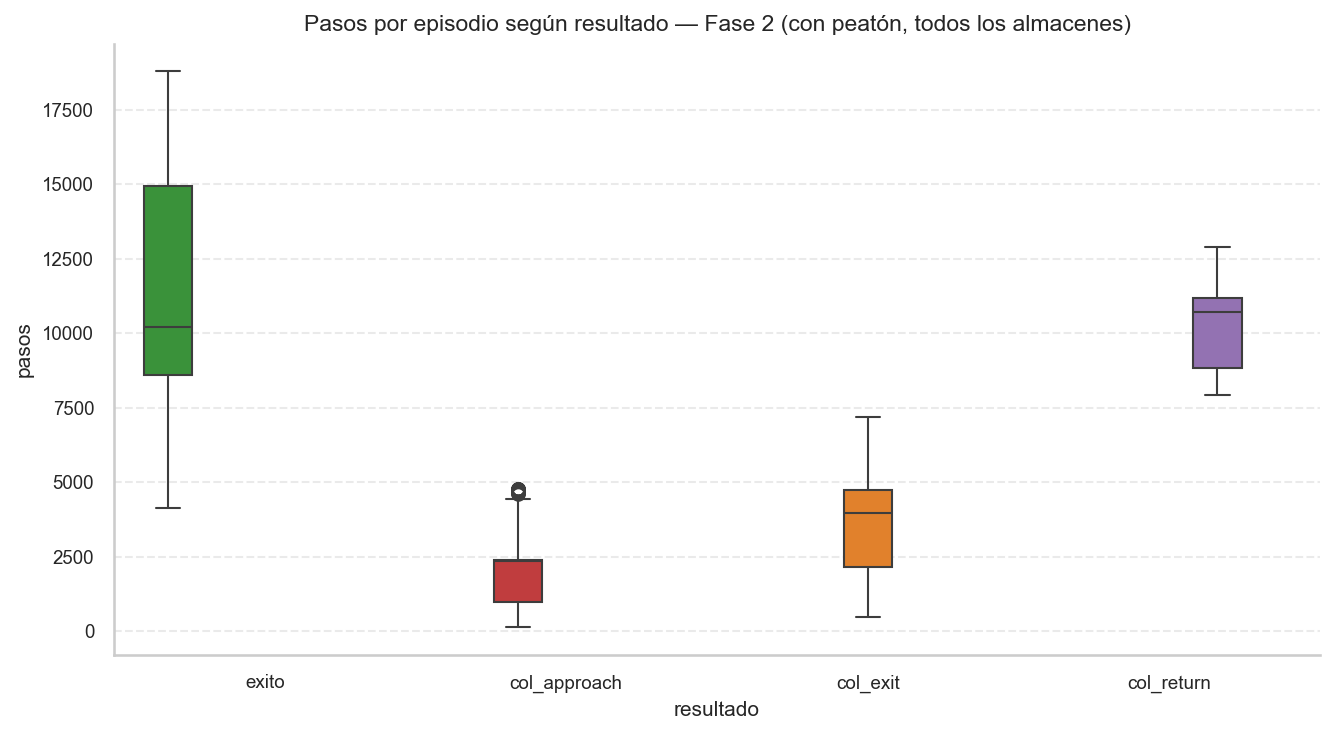

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df2, x="resultado", y="pasos",
            order=[r for r in RESULTADO_ORDEN if r in df2["resultado"].unique()], ax=ax,
            hue="resultado", palette=RESULTADO_COLOR, legend=False)
ax.set_title("Pasos por episodio según resultado — Fase 2 (con peatón, todos los almacenes)")
plt.tight_layout()
guardar(fig, "12_pasos_por_resultado")
plt.show()


### Análisis de outliers
Igual que en fase 1: se marca como outlier todo episodio fuera de 1.5×IQR respecto a su grupo almacén+método, por separado para `pasos` y para `reward`. Con peatón, además de las colisiones, cabe esperar que algunos éxitos sean outliers genuinos (esquivar al peatón añadiendo un rodeo).

In [28]:
def marcar_outliers_iqr2(df, col, by=("warehouse_id", "metodo")):
    def _outlier(s):
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return df.groupby(list(by), observed=True)[col].transform(_outlier)

df2["outlier_pasos"] = marcar_outliers_iqr2(df2, "pasos")
df2["outlier_reward"] = marcar_outliers_iqr2(df2, "reward")
df2["outlier_alguno"] = df2["outlier_pasos"] | df2["outlier_reward"]

n_por_resultado2 = df2.groupby("resultado", observed=False).size()
tabla_outliers2 = pd.DataFrame({
    "n_episodios": n_por_resultado2,
    "outliers_pasos": df2[df2["outlier_pasos"]].groupby("resultado", observed=False).size(),
    "outliers_reward": df2[df2["outlier_reward"]].groupby("resultado", observed=False).size(),
}).fillna(0).astype({"outliers_pasos": int, "outliers_reward": int})
tabla_outliers2["%_outliers_pasos"] = (tabla_outliers2["outliers_pasos"] / tabla_outliers2["n_episodios"] * 100).round(1)
tabla_outliers2["%_outliers_reward"] = (tabla_outliers2["outliers_reward"] / tabla_outliers2["n_episodios"] * 100).round(1)

n_outliers_total2 = df2["outlier_alguno"].sum()
print(f"Total episodios marcados como outlier (pasos y/o reward): {n_outliers_total2} / {len(df2)}")
tabla_outliers2


Total episodios marcados como outlier (pasos y/o reward): 12824 / 81360


,n_episodios,outliers_pasos,outliers_reward,%_outliers_pasos,%_outliers_reward
resultado,,,,,
exito,68461,35,27,0.1,0.0
col_approach,3099,3099,3099,100.0,100.0
col_exit,3796,3510,3796,92.5,100.0
col_return,6004,4739,5892,78.9,98.1
truncado,0,0,0,NaN,NaN


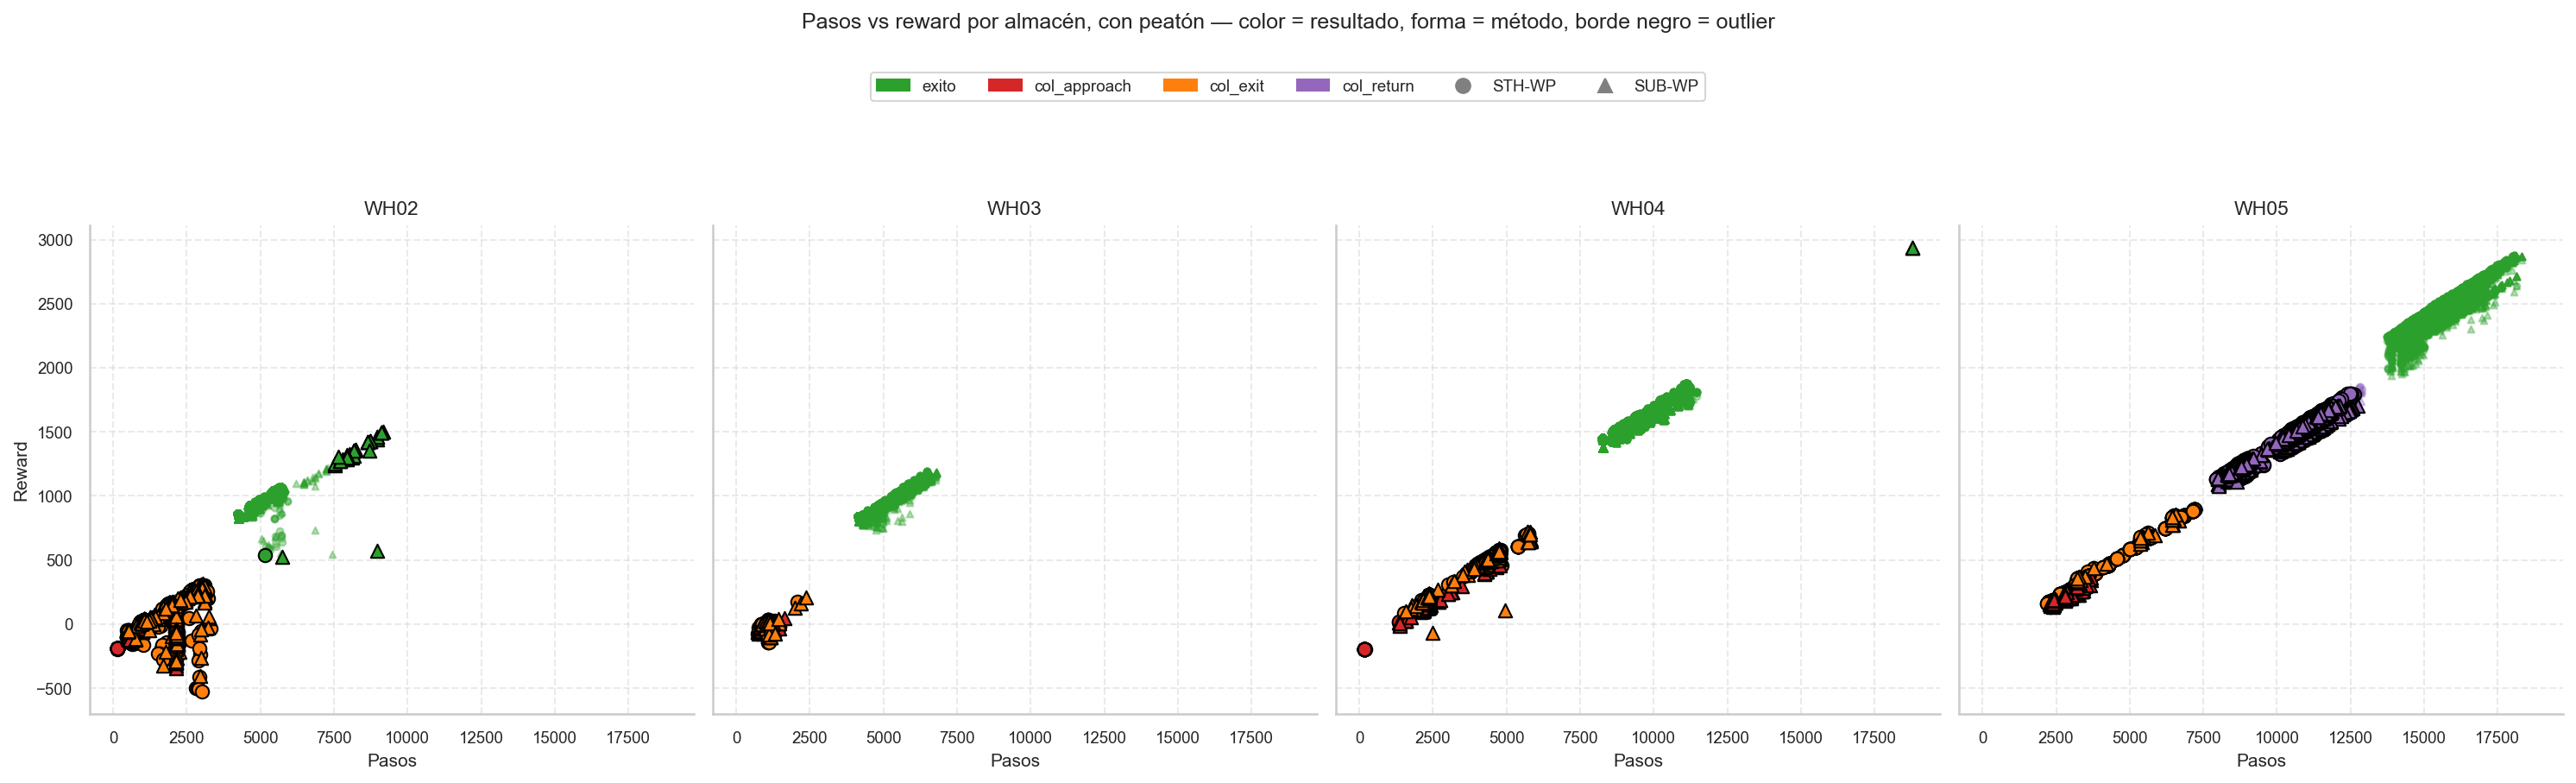

In [29]:
marker_metodo = {"sthwp": "o", "subwp": "^"}

fig, axes = plt.subplots(1, len(WH_ORDEN), figsize=(5 * len(WH_ORDEN), 5), sharex=True, sharey=True)
for ax, wh in zip(axes, WH_ORDEN):
    sub_wh = df2[df2["warehouse_id"] == wh]
    for metodo in METODO_ORDEN:
        sub_m = sub_wh[sub_wh["metodo"] == metodo]
        for resultado in RESULTADO_ORDEN:
            sub = sub_m[sub_m["resultado"] == resultado]
            if sub.empty:
                continue
            normales = sub[~sub["outlier_alguno"]]
            atipicos = sub[sub["outlier_alguno"]]
            ax.scatter(normales["pasos"], normales["reward"], color=RESULTADO_COLOR[resultado],
                       marker=marker_metodo[metodo], s=14, alpha=0.35)
            if not atipicos.empty:
                ax.scatter(atipicos["pasos"], atipicos["reward"], facecolor=RESULTADO_COLOR[resultado],
                           edgecolor="black", linewidth=1.0, marker=marker_metodo[metodo], s=55, zorder=5)
    ax.set_title(f"WH{wh}")
    ax.set_xlabel("Pasos")
axes[0].set_ylabel("Reward")

leyenda_color = [mpatches.Patch(color=RESULTADO_COLOR[r], label=r)
                 for r in RESULTADO_ORDEN if r in df2["resultado"].unique()]
leyenda_marker = [plt.Line2D([0], [0], marker=marker_metodo[m], color="gray", linestyle="",
                              markersize=8, label=METODO_LABEL[m]) for m in METODO_ORDEN]
fig.legend(handles=leyenda_color + leyenda_marker, loc="upper center",
           ncol=len(leyenda_color) + len(leyenda_marker), bbox_to_anchor=(0.5, 1.12))
fig.suptitle("Pasos vs reward por almacén, con peatón — color = resultado, forma = método, borde negro = outlier", y=1.2)
plt.tight_layout()
guardar(fig, "12b_outliers_pasos_vs_reward")
plt.show()


## 10. Mapa espacial de éxito por goal
Color continuo: tasa de éxito del goal a lo largo de sus 10 repeticiones.

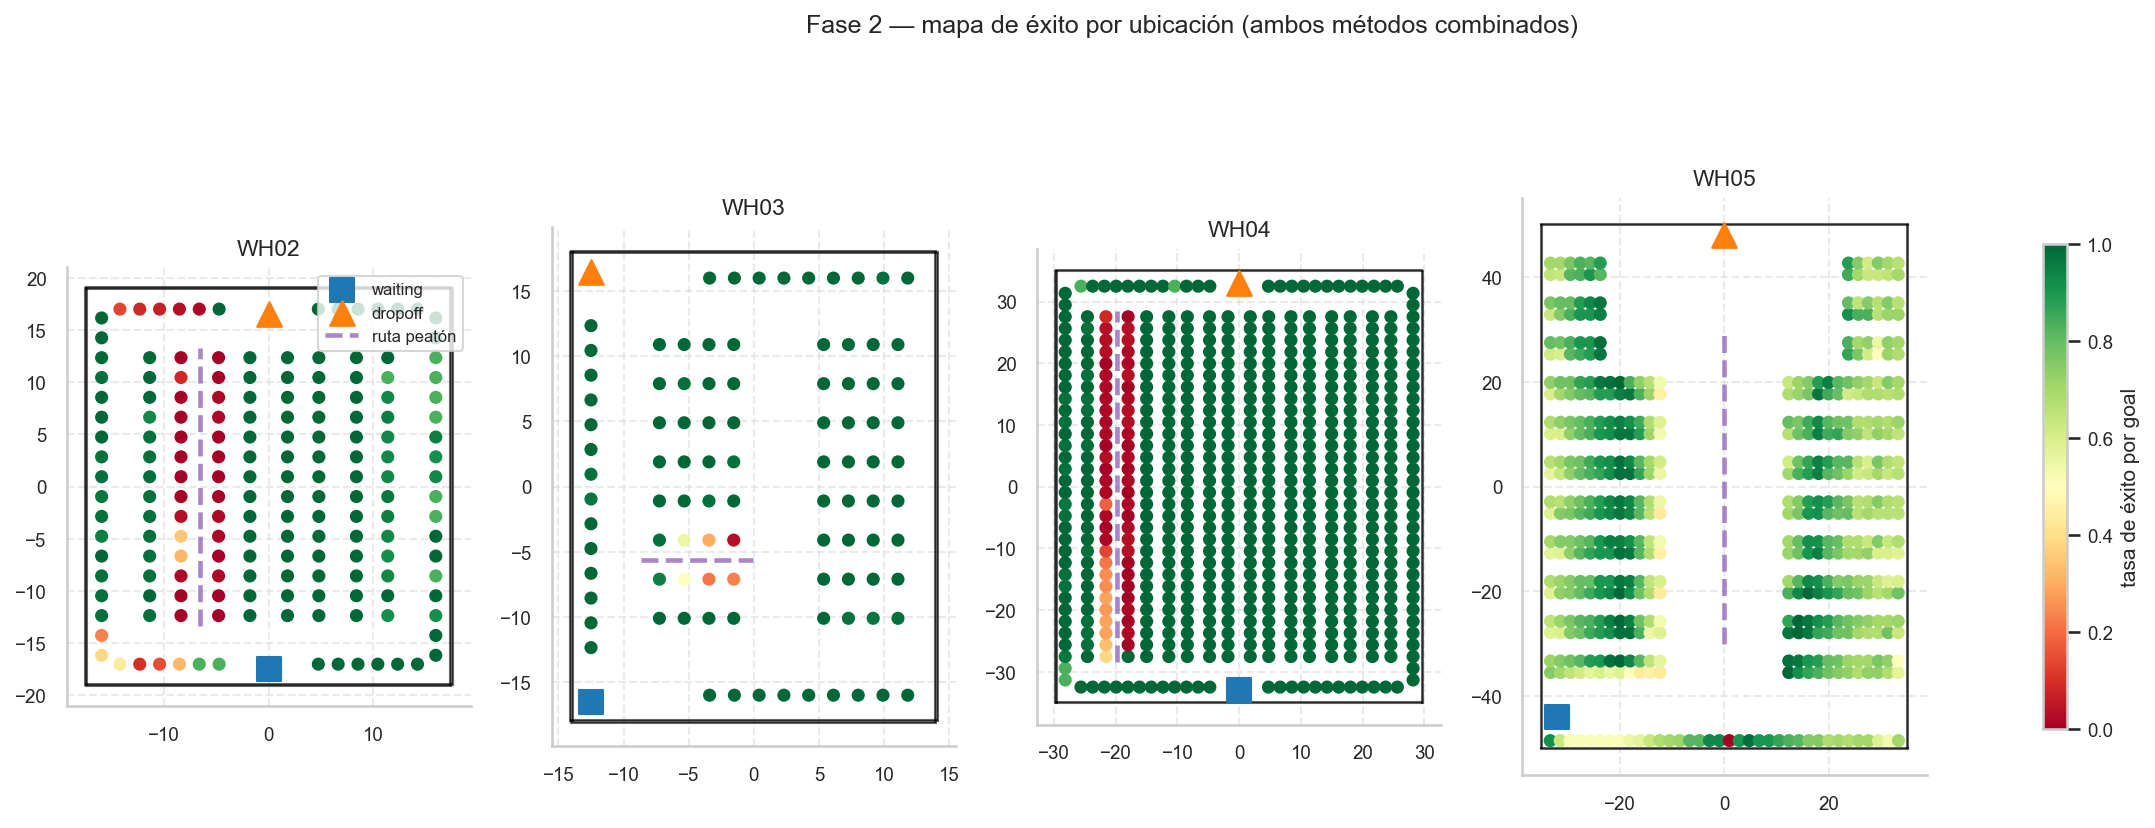

In [30]:
PASILLO_PEATON = {
    "02": ((-6.6, -13.3), (-6.6, 13.3)),
    "03": ((-8.7, -5.6), (-0.1, -5.6)),
    "04": ((-19.8, -28.5), (-19.8, 28.5)),
    "05": ((0.0, -30.0), (0.0, 30.0)),
}

def cargar_mapa(wh):
    with open(STHWP_DIR / f"warehouse_map{wh}.json") as f:
        return json.load(f)

def plot_almacen2(ax, wh, df_wh):
    mapa = cargar_mapa(wh)
    for wall in mapa["walls"]:
        rect = mpatches.Rectangle(
            (wall["x"] - wall["w"] / 2, wall["y"] - wall["h"] / 2), wall["w"], wall["h"],
            color="black", alpha=0.6)
        ax.add_patch(rect)
    zonas = mapa["zones"]
    ax.scatter(*zonas["waiting"].values(), marker="s", s=140, color="#1f77b4", label="waiting", zorder=5)
    ax.scatter(*zonas["dropoff"].values(), marker="^", s=140, color="#ff7f0e", label="dropoff", zorder=5)

    (px1, py1), (px2, py2) = PASILLO_PEATON[wh]
    ax.plot([px1, px2], [py1, py2], color="#9467bd", linestyle="--", linewidth=2.2,
            alpha=0.8, label="ruta peatón", zorder=3)

    tasa_goal = df_wh.groupby("goal_id", observed=True)["exito_bool"].mean()
    coords = {s["goal_id"]: (s["goal_x"], s["goal_y"]) for s in mapa["shelves"]}
    xs, ys, colores = [], [], []
    for gid, tasa in tasa_goal.items():
        if gid not in coords:
            continue
        x, y = coords[gid]
        xs.append(x); ys.append(y)
        colores.append(tasa)
    sc = ax.scatter(xs, ys, c=colores, cmap="RdYlGn", vmin=0, vmax=1, s=28, zorder=4)
    ax.set_title(f"WH{wh}")
    ax.set_aspect("equal")
    return sc

whs_con_datos = [wh for wh in WH_ORDEN if not df2[df2["warehouse_id"] == wh].empty]
if whs_con_datos:
    fig, axes = plt.subplots(1, len(whs_con_datos), figsize=(5 * len(whs_con_datos), 6))
    if len(whs_con_datos) == 1:
        axes = [axes]
    for ax, wh in zip(axes, whs_con_datos):
        sub = df2[df2["warehouse_id"] == wh]
        sc = plot_almacen2(ax, wh, sub)
    axes[0].legend(loc="upper right", fontsize=8)
    cbar = fig.colorbar(sc, ax=axes, shrink=0.7, label="tasa de éxito por goal")
    fig.suptitle("Fase 2 — mapa de éxito por ubicación (ambos métodos combinados)", y=1.02)
    guardar(fig, "09_mapa_espacial_exito")
    plt.show()
else:
    print("Todavía no hay datos suficientes para el mapa espacial.")


### Mapa por seed y método
El mapa combinado de arriba promedia las 3 seeds y los 2 métodos. Aquí se desglosa cada almacén en una rejilla de 6 paneles (2 métodos × 3 seeds) — color continuo porque cada goal tiene 10 repeticiones por seed/método (no es binario como en fase 1).

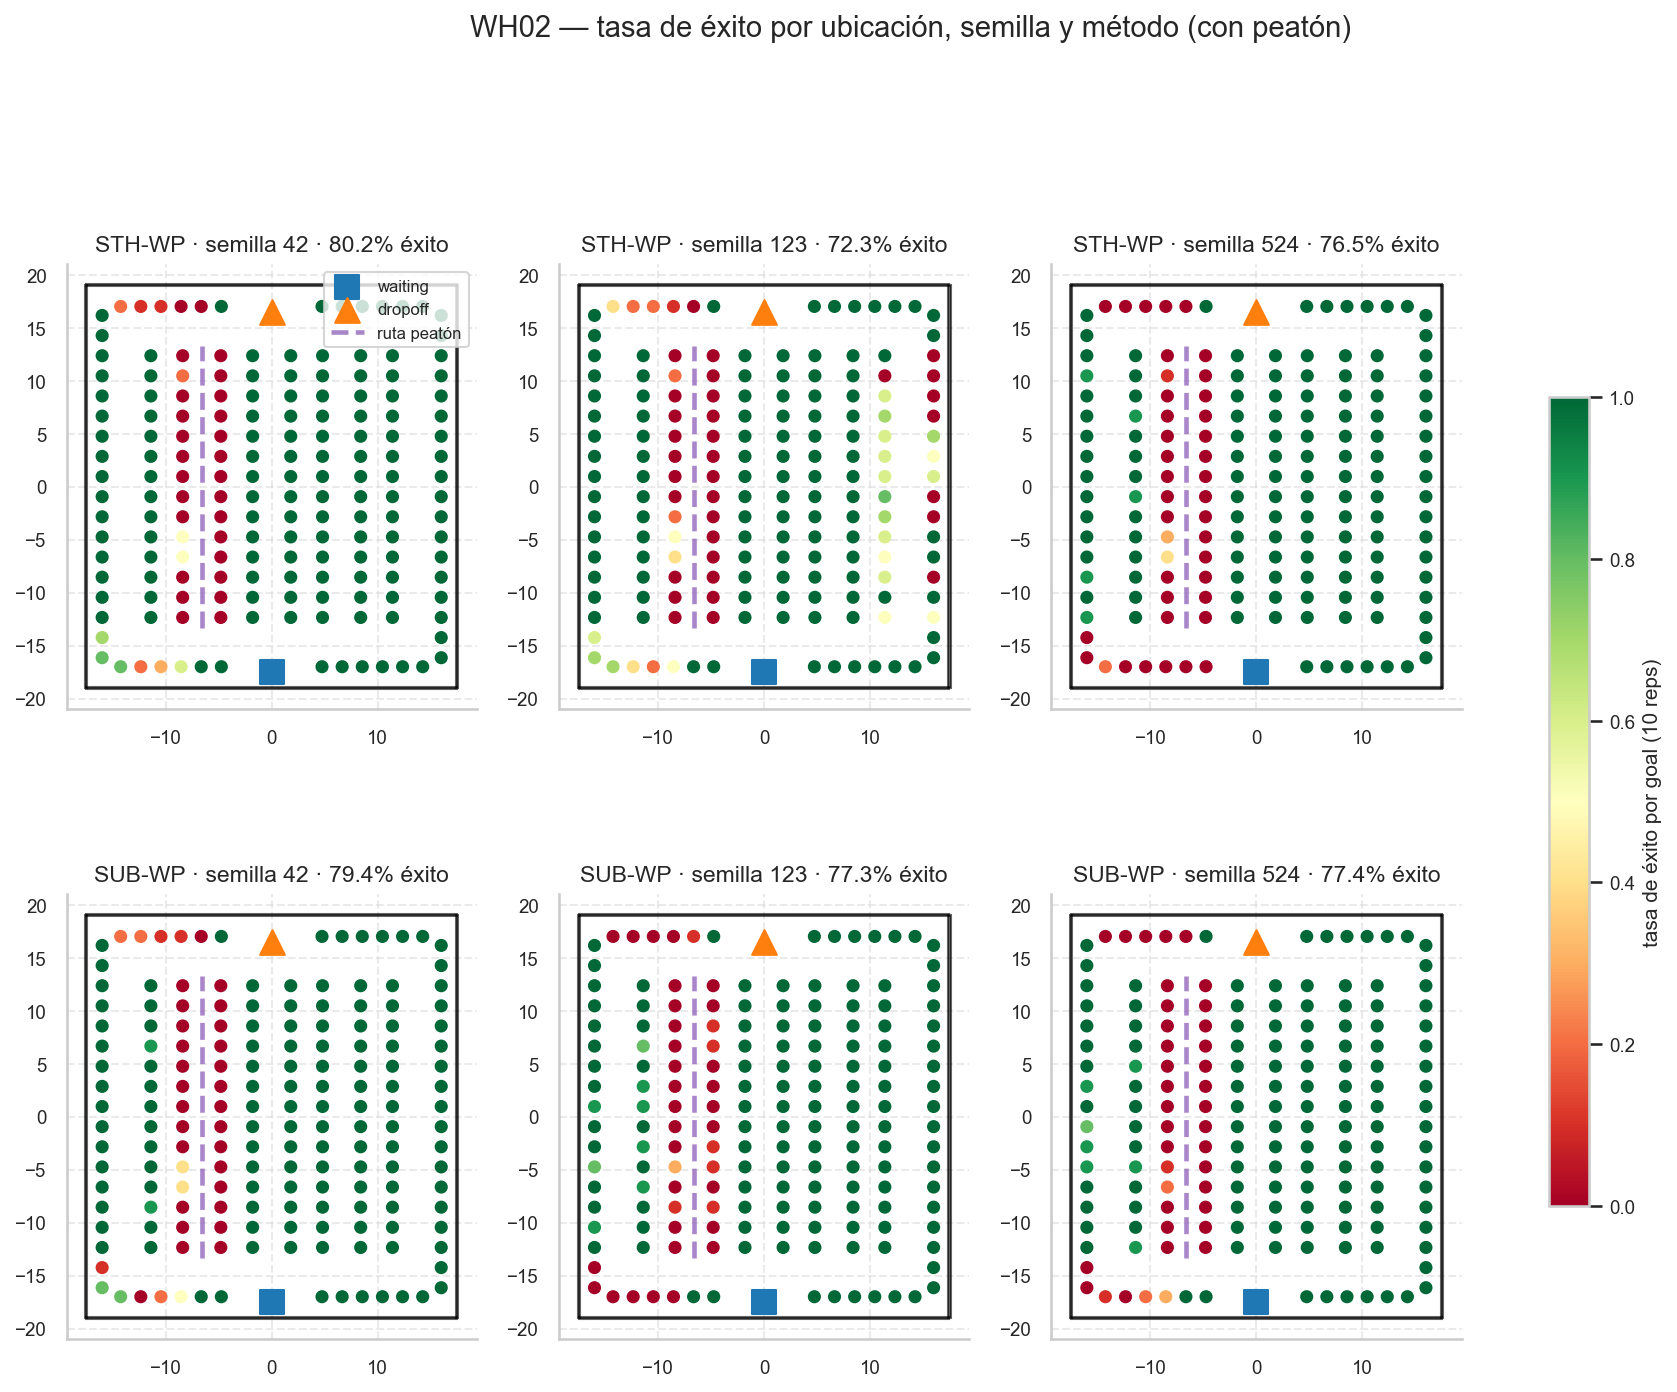

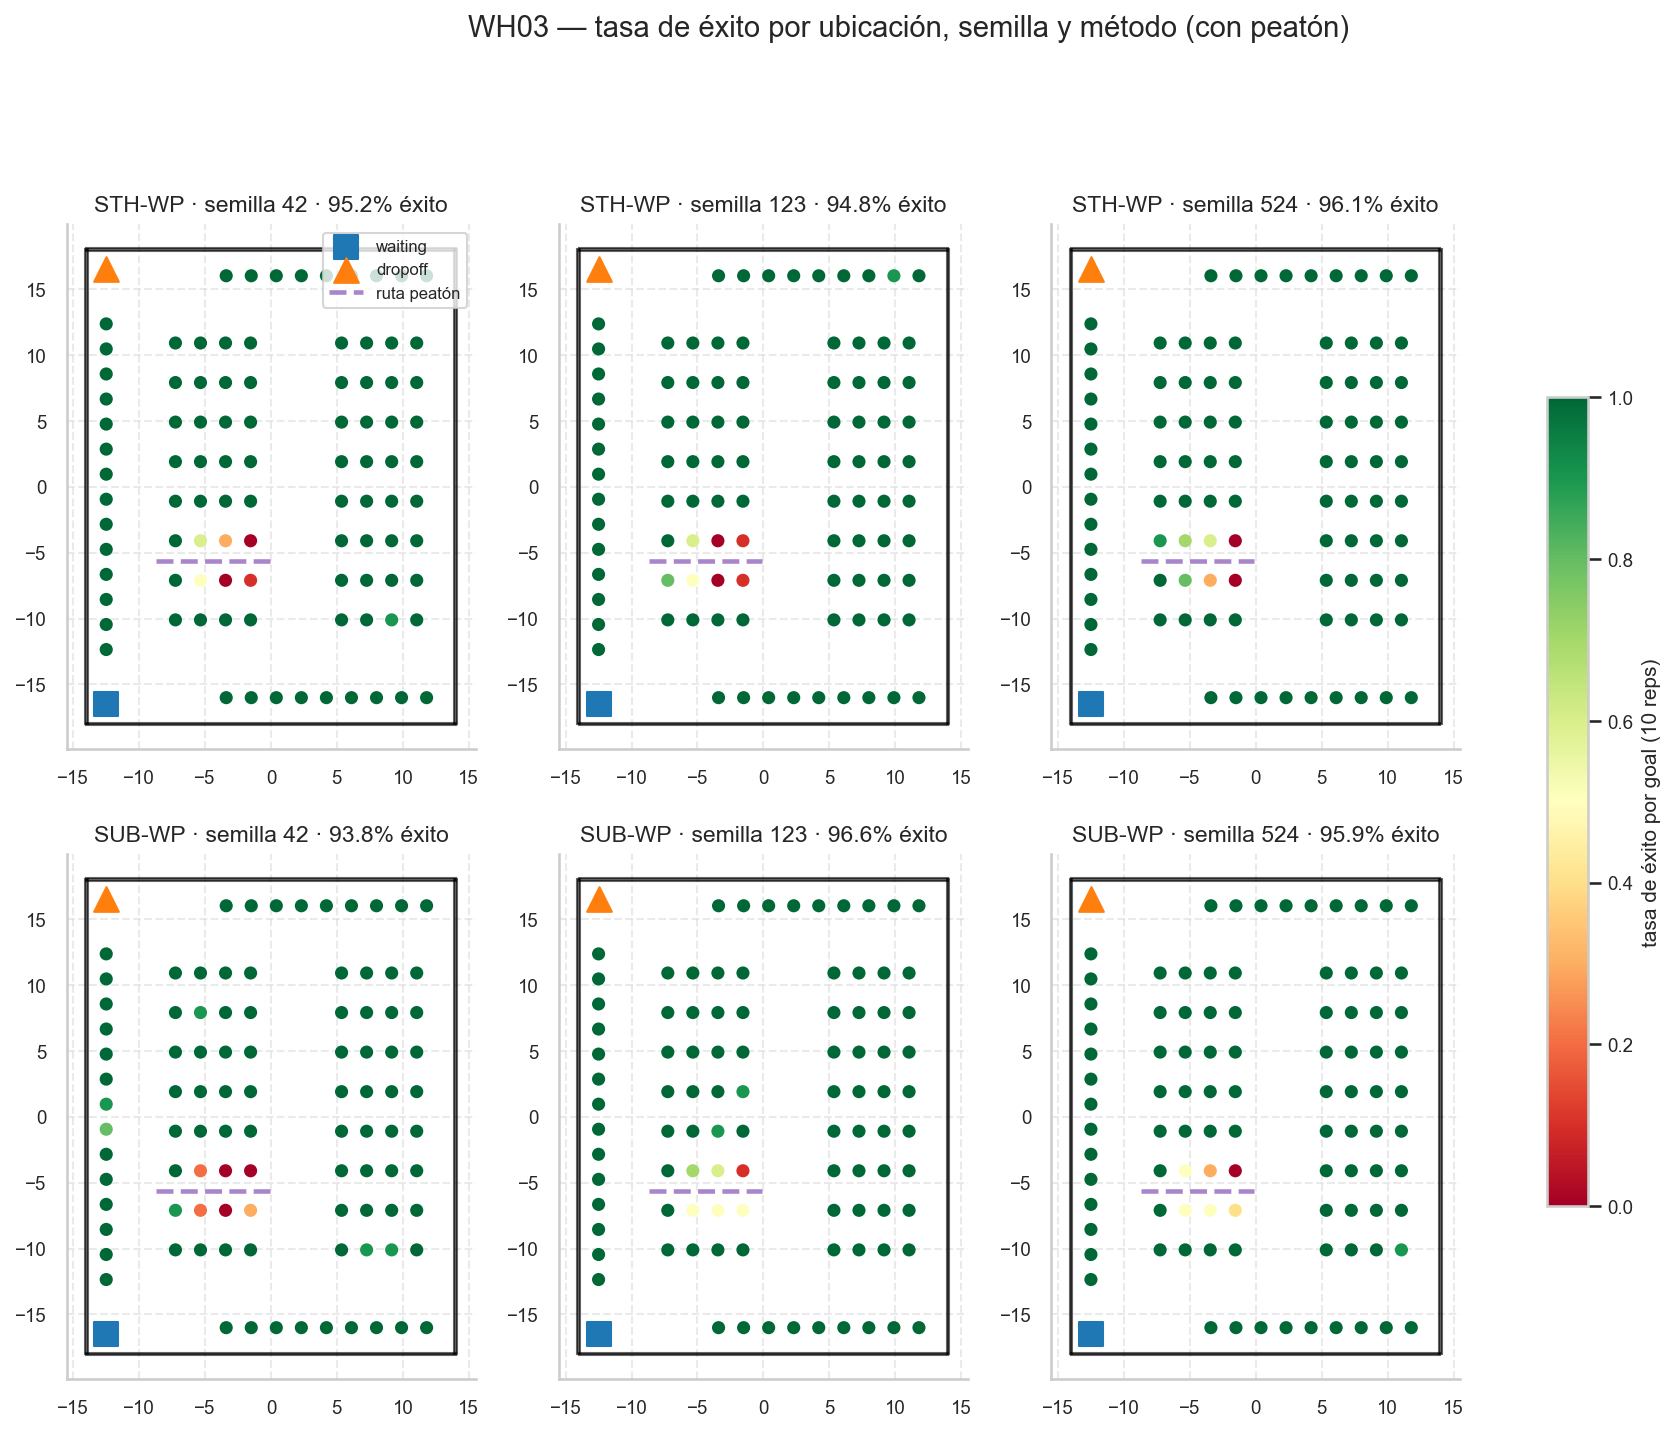

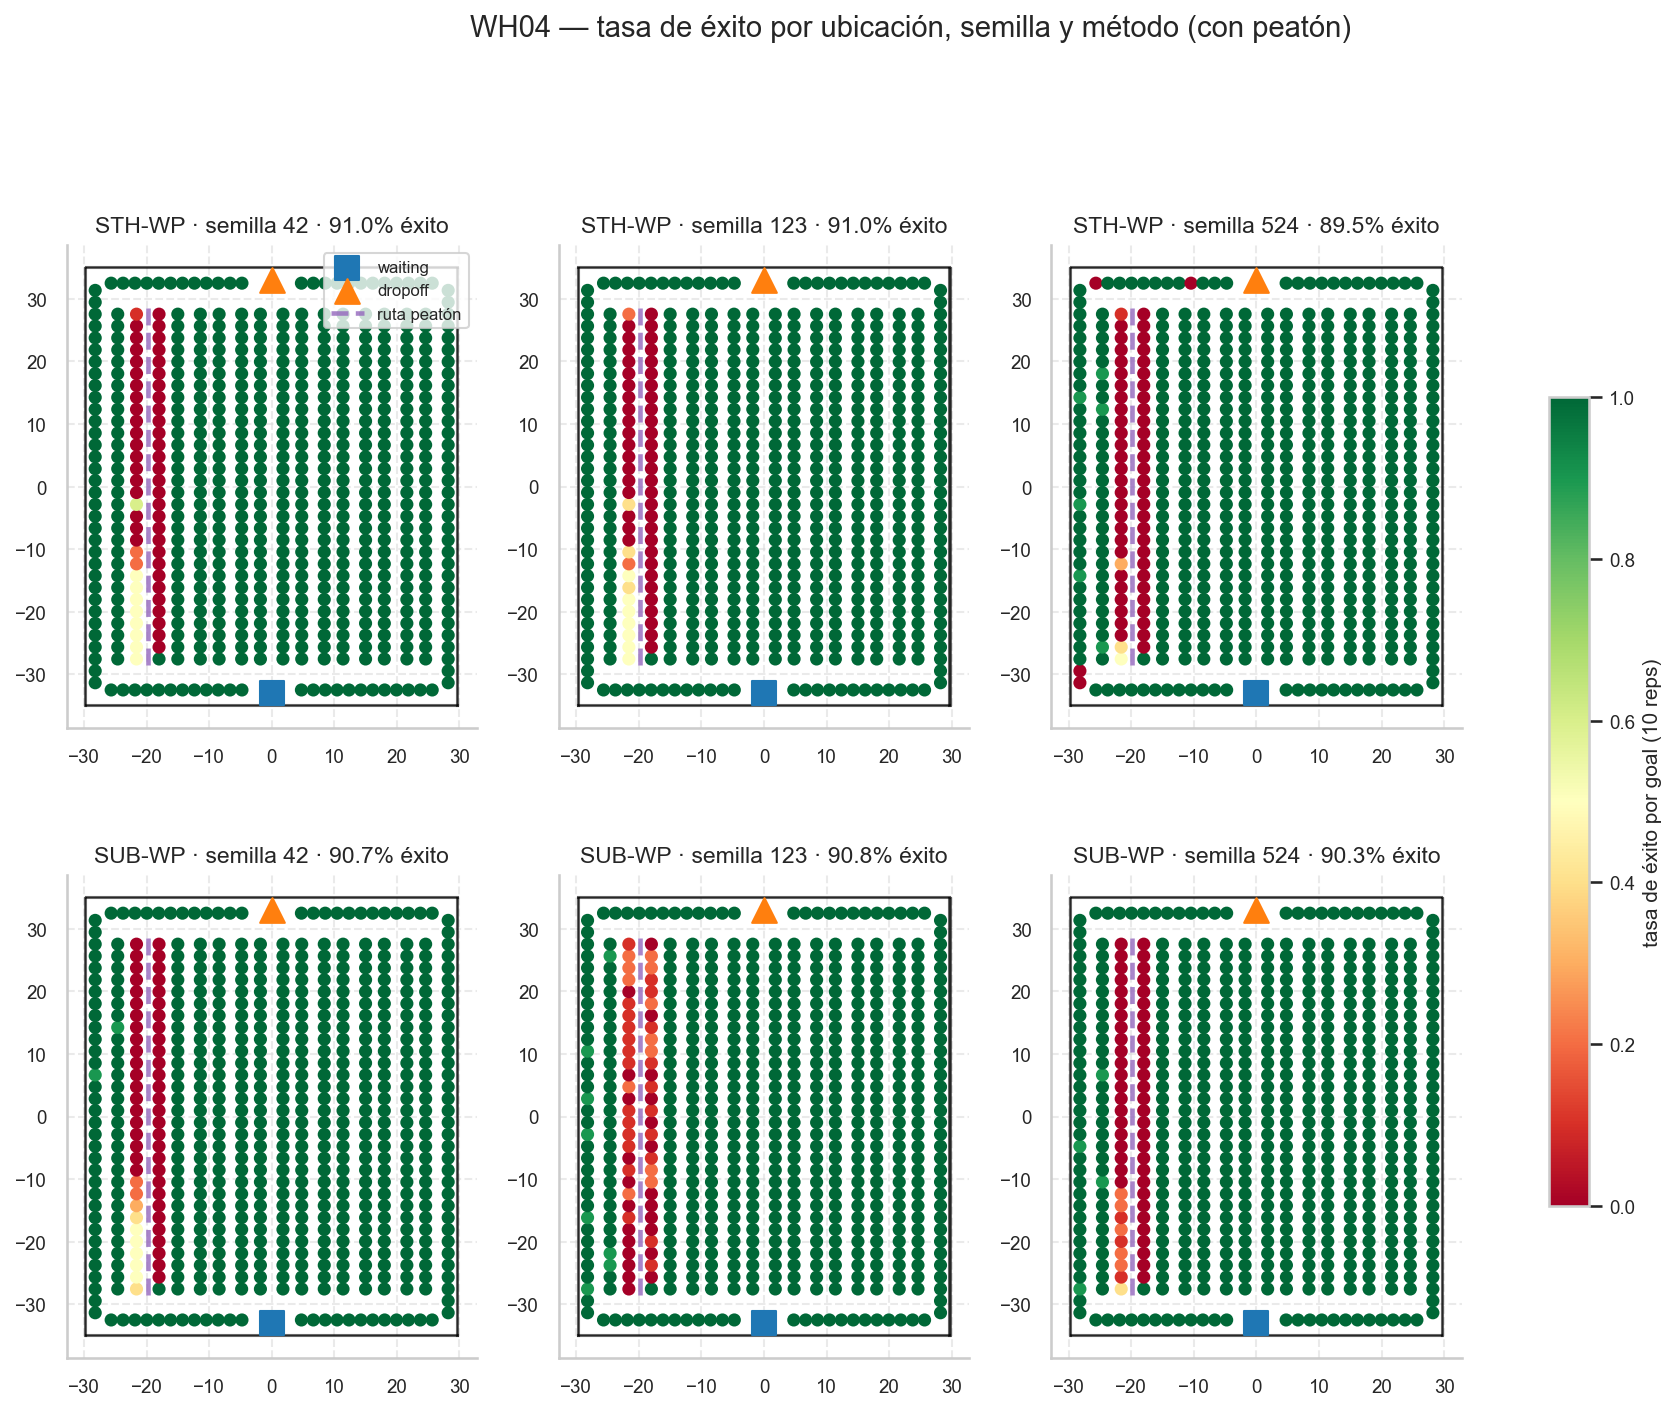

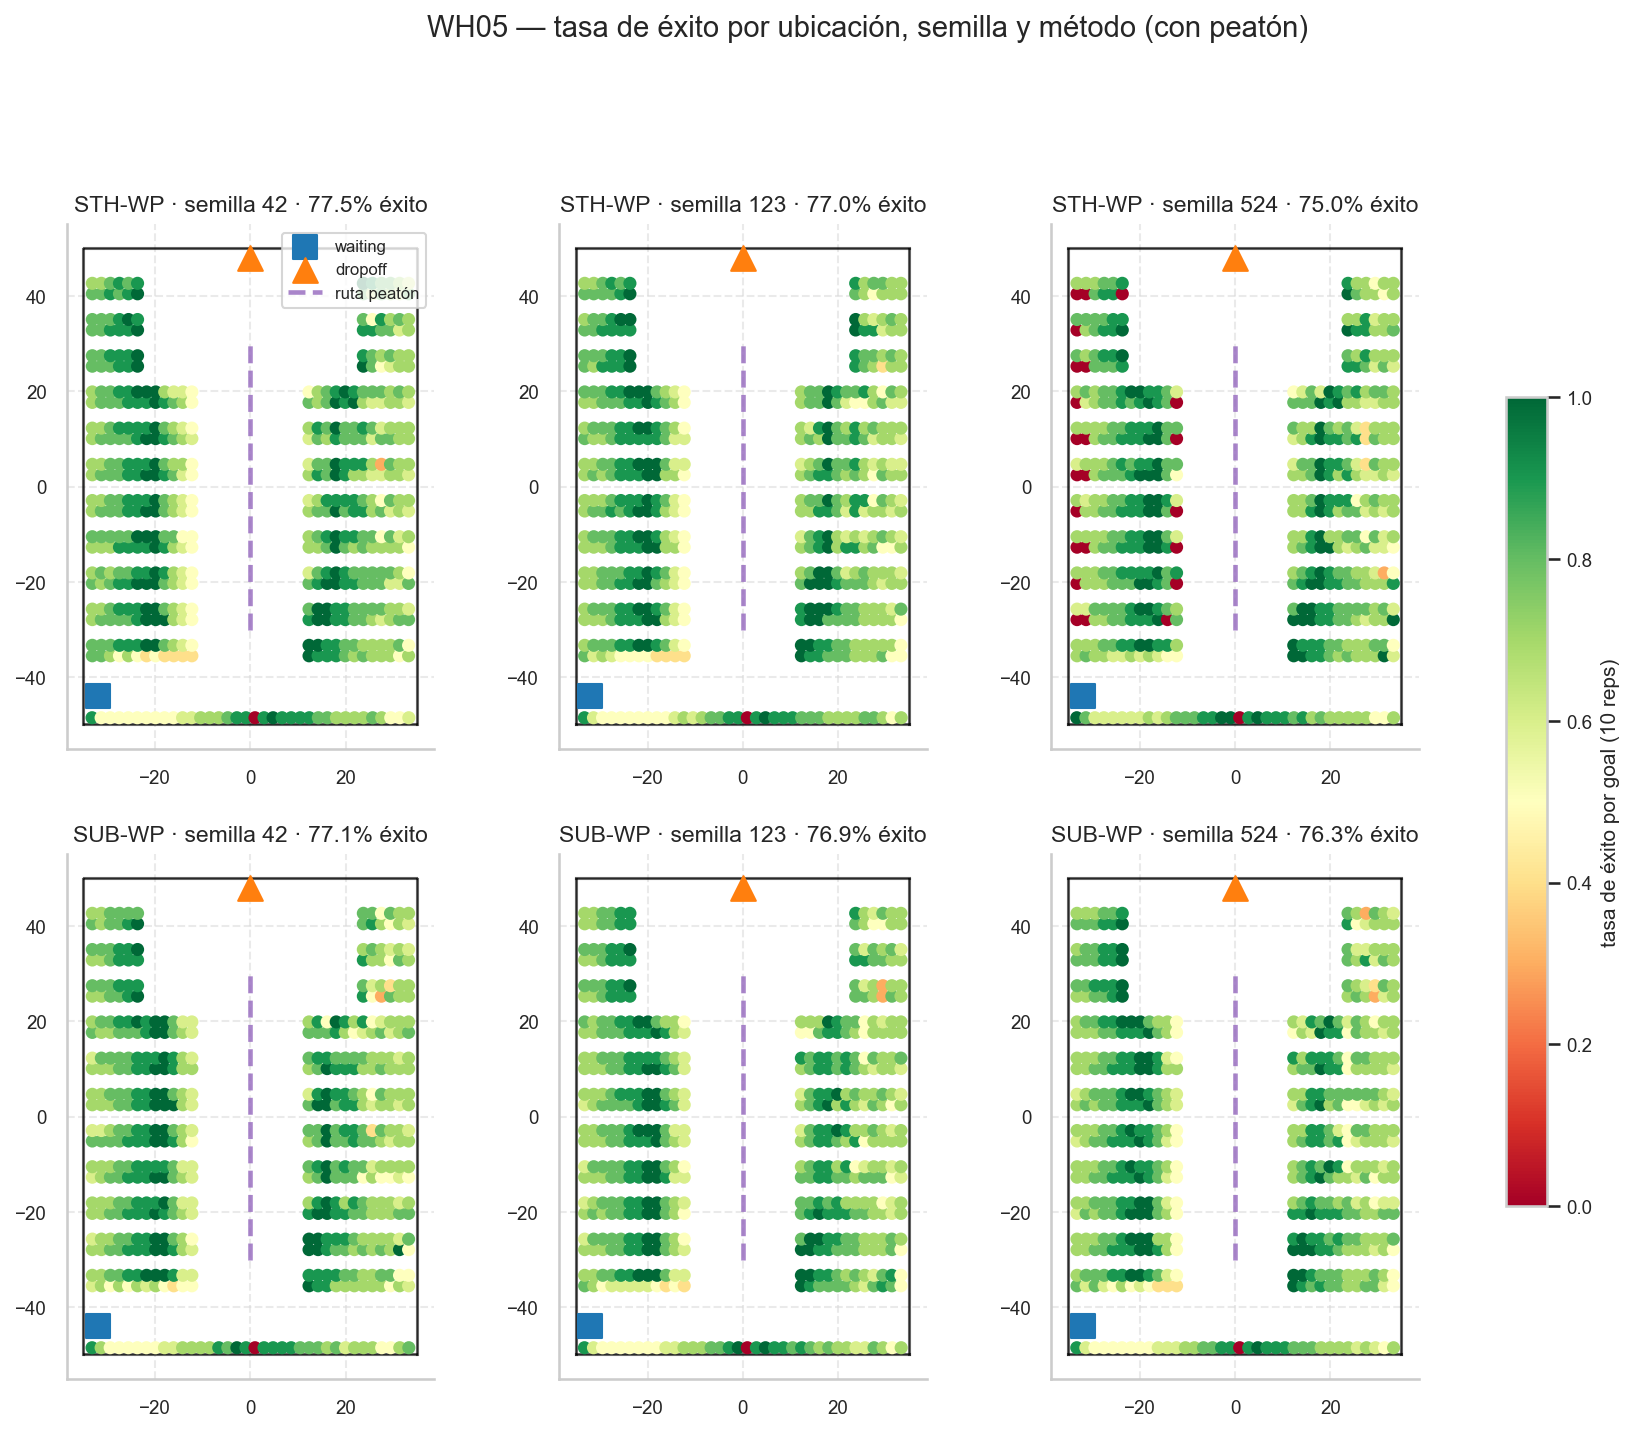

In [31]:
for wh in WH_ORDEN:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    seeds_orden = sorted(df2["seed"].unique(), key=lambda s: SEEDS.index(s) if s in SEEDS else 99)
    sc = None
    for i, metodo in enumerate(METODO_ORDEN):
        for j, seed in enumerate(seeds_orden):
            ax = axes[i, j]
            sub = df2[(df2["warehouse_id"] == wh) & (df2["metodo"] == metodo) & (df2["seed"] == seed)]
            if sub.empty:
                ax.set_title(f"{METODO_LABEL[metodo]} · semilla {seed} (sin datos)")
                ax.set_xticks([]); ax.set_yticks([])
                continue
            sc = plot_almacen2(ax, wh, sub)
            tasa_media = sub["exito_bool"].mean() * 100
            ax.set_title(f"{METODO_LABEL[metodo]} · semilla {seed} · {tasa_media:.1f}% éxito")
    if sc is not None:
        axes[0, 0].legend(loc="upper right", fontsize=8)
        cbar = fig.colorbar(sc, ax=axes, shrink=0.7, label="tasa de éxito por goal (10 reps)")
    fig.suptitle(f"WH{wh} — tasa de éxito por ubicación, semilla y método (con peatón)", y=1.02, fontsize=14)
    guardar(fig, f"13_mapa_seed_metodo_WH{wh}")
    plt.show()


### Tipo de fallo predominante por goal
Los mapas anteriores muestran *cuánto* falla cada goal, pero no *de qué tipo*. Aquí se colorea cada goal según su resultado predominante entre sus repeticiones (`exito`, `col_approach`, `col_exit`, `col_return`...) — la opacidad indica la pureza (100% de las reps de acuerdo = opaco; mitad y mitad = translúcido).

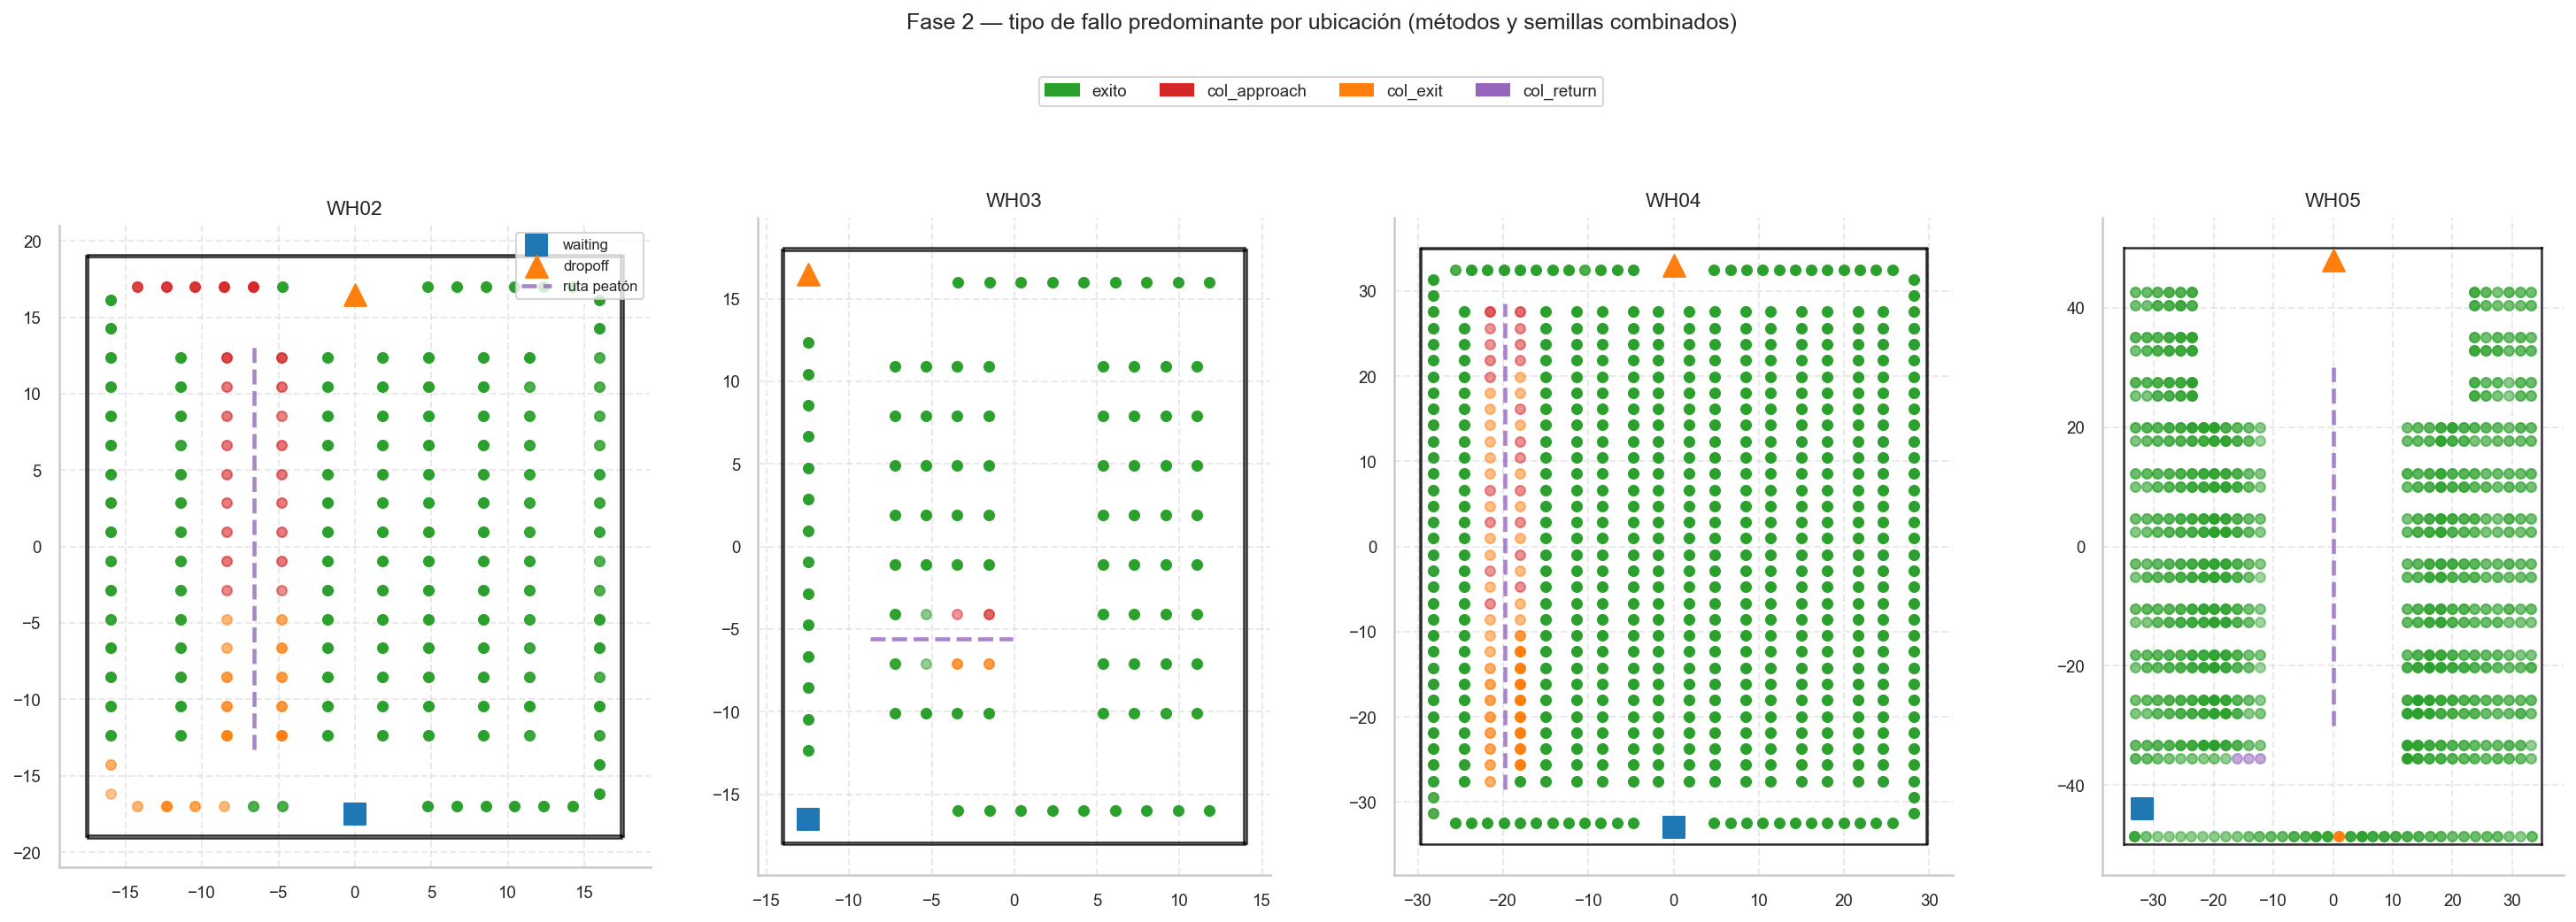

In [32]:
def plot_almacen2_tipo_fallo(ax, wh, df_wh):
    mapa = cargar_mapa(wh)
    for wall in mapa["walls"]:
        rect = mpatches.Rectangle(
            (wall["x"] - wall["w"] / 2, wall["y"] - wall["h"] / 2), wall["w"], wall["h"],
            color="black", alpha=0.6)
        ax.add_patch(rect)
    zonas = mapa["zones"]
    ax.scatter(*zonas["waiting"].values(), marker="s", s=140, color="#1f77b4", label="waiting", zorder=5)
    ax.scatter(*zonas["dropoff"].values(), marker="^", s=140, color="#ff7f0e", label="dropoff", zorder=5)
    (px1, py1), (px2, py2) = PASILLO_PEATON[wh]
    ax.plot([px1, px2], [py1, py2], color="#9467bd", linestyle="--", linewidth=2.2,
            alpha=0.8, label="ruta peatón", zorder=3)

    coords = {s["goal_id"]: (s["goal_x"], s["goal_y"]) for s in mapa["shelves"]}
    conteos = df_wh.groupby(["goal_id", "resultado"], observed=False).size().unstack("resultado").fillna(0)
    for gid, fila in conteos.iterrows():
        if gid not in coords or fila.sum() == 0:
            continue
        x, y = coords[gid]
        dominante = fila.idxmax()
        pureza = fila[dominante] / fila.sum()
        ax.scatter(x, y, color=RESULTADO_COLOR[dominante], alpha=max(pureza, 0.15), s=28, zorder=4)
    ax.set_title(f"WH{wh}")
    ax.set_aspect("equal")


fig, axes = plt.subplots(1, len(WH_ORDEN), figsize=(5 * len(WH_ORDEN), 6))
for ax, wh in zip(axes, WH_ORDEN):
    sub = df2[df2["warehouse_id"] == wh]
    plot_almacen2_tipo_fallo(ax, wh, sub)
axes[0].legend(loc="upper right", fontsize=8)
leyenda_tipo = [mpatches.Patch(color=RESULTADO_COLOR[r], label=r) for r in RESULTADO_ORDEN if r in df2["resultado"].unique()]
fig.legend(handles=leyenda_tipo, loc="upper center", ncol=len(leyenda_tipo), bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Fase 2 — tipo de fallo predominante por ubicación (métodos y semillas combinados)", y=1.15)
plt.tight_layout()
guardar(fig, "14_tipo_fallo_predominante")
plt.show()


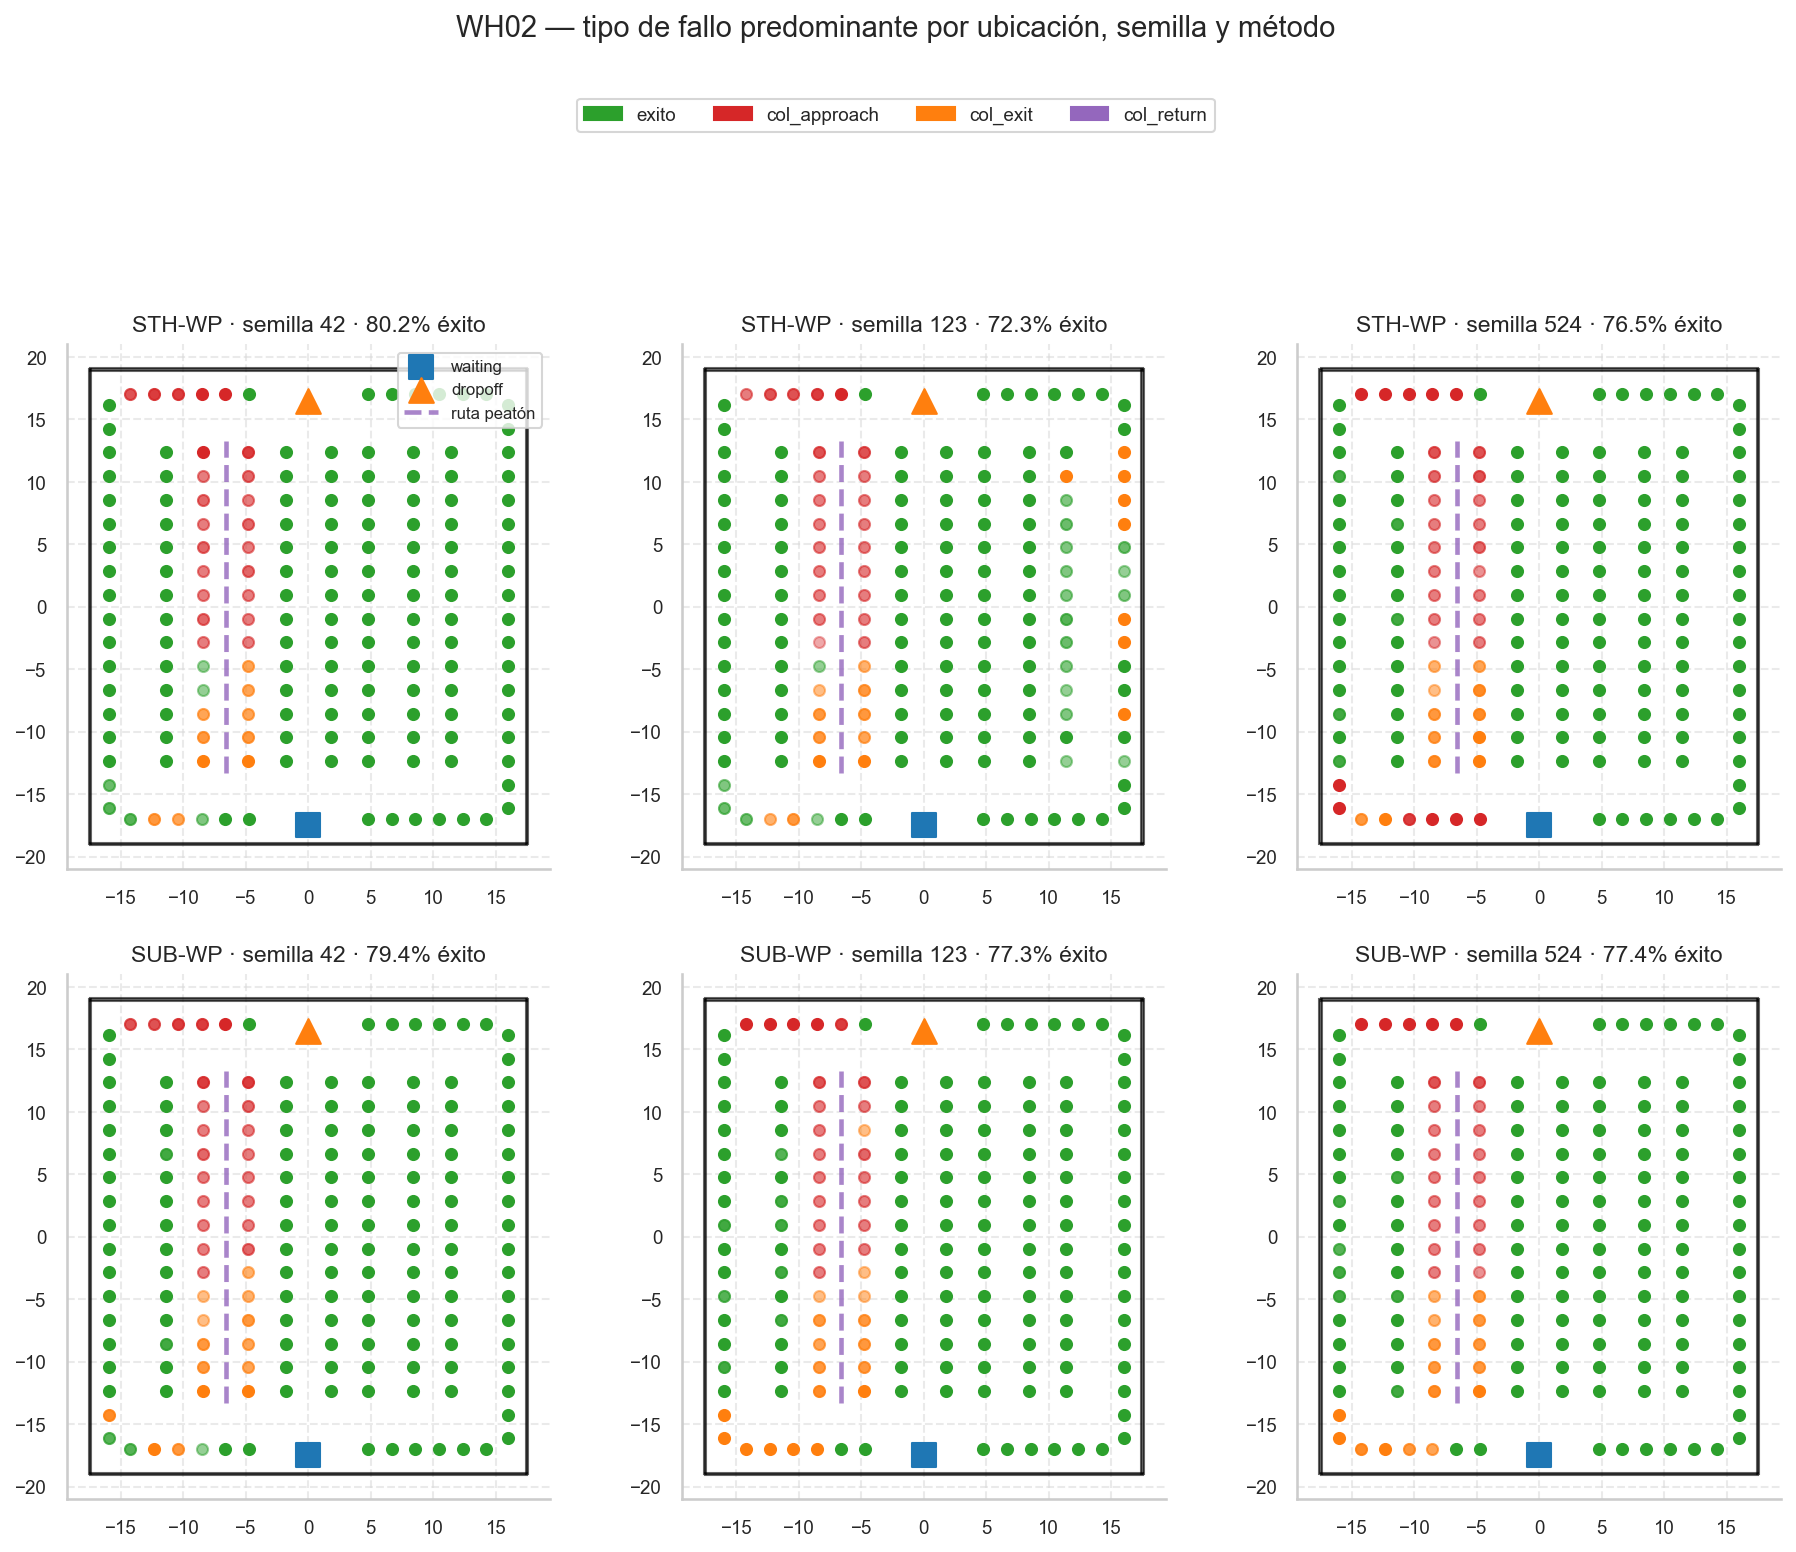

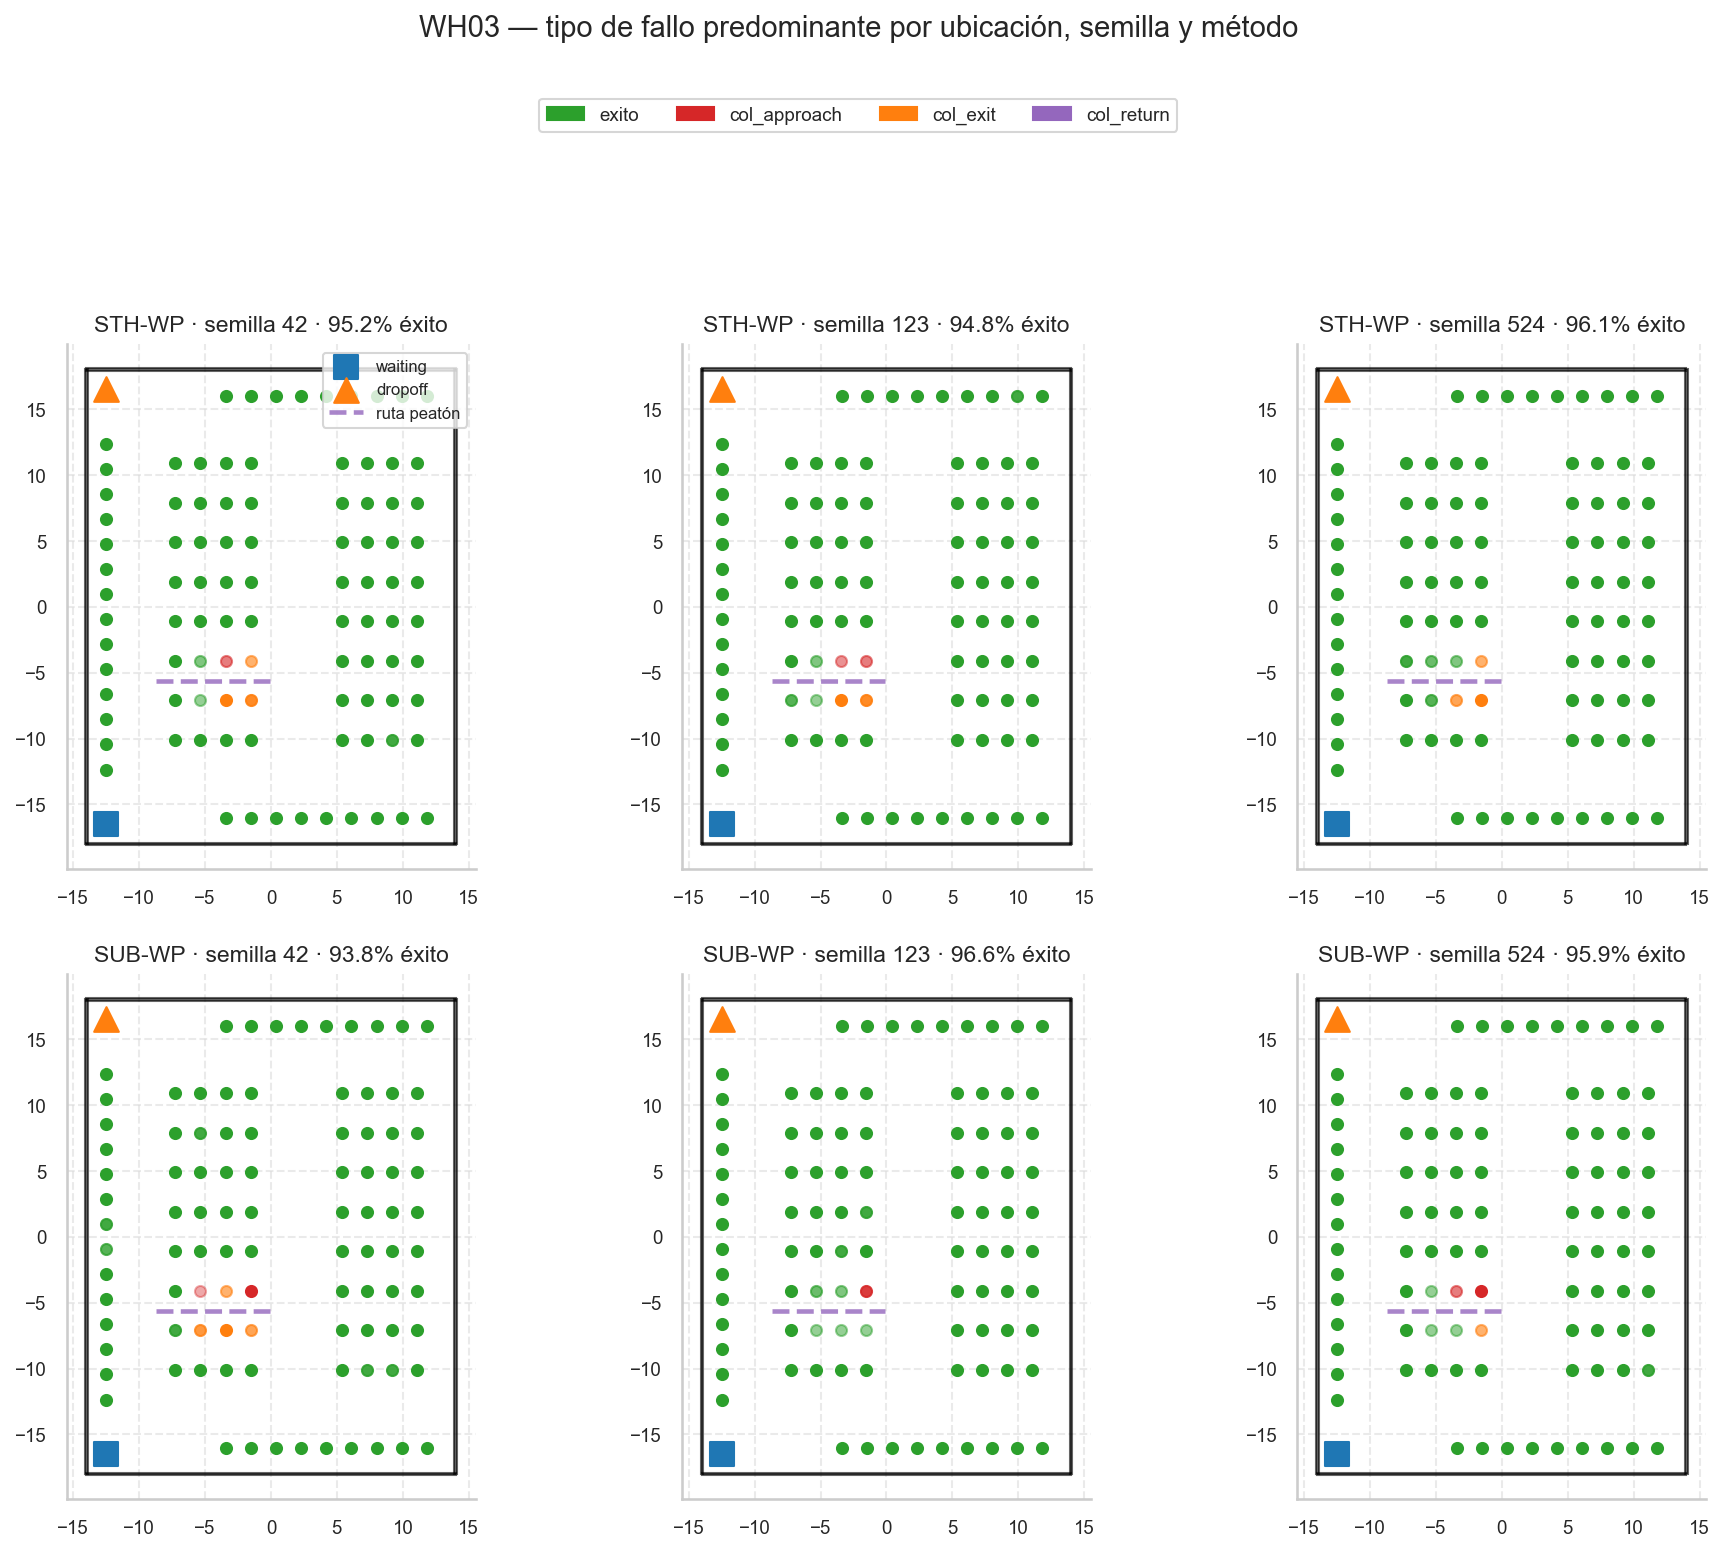

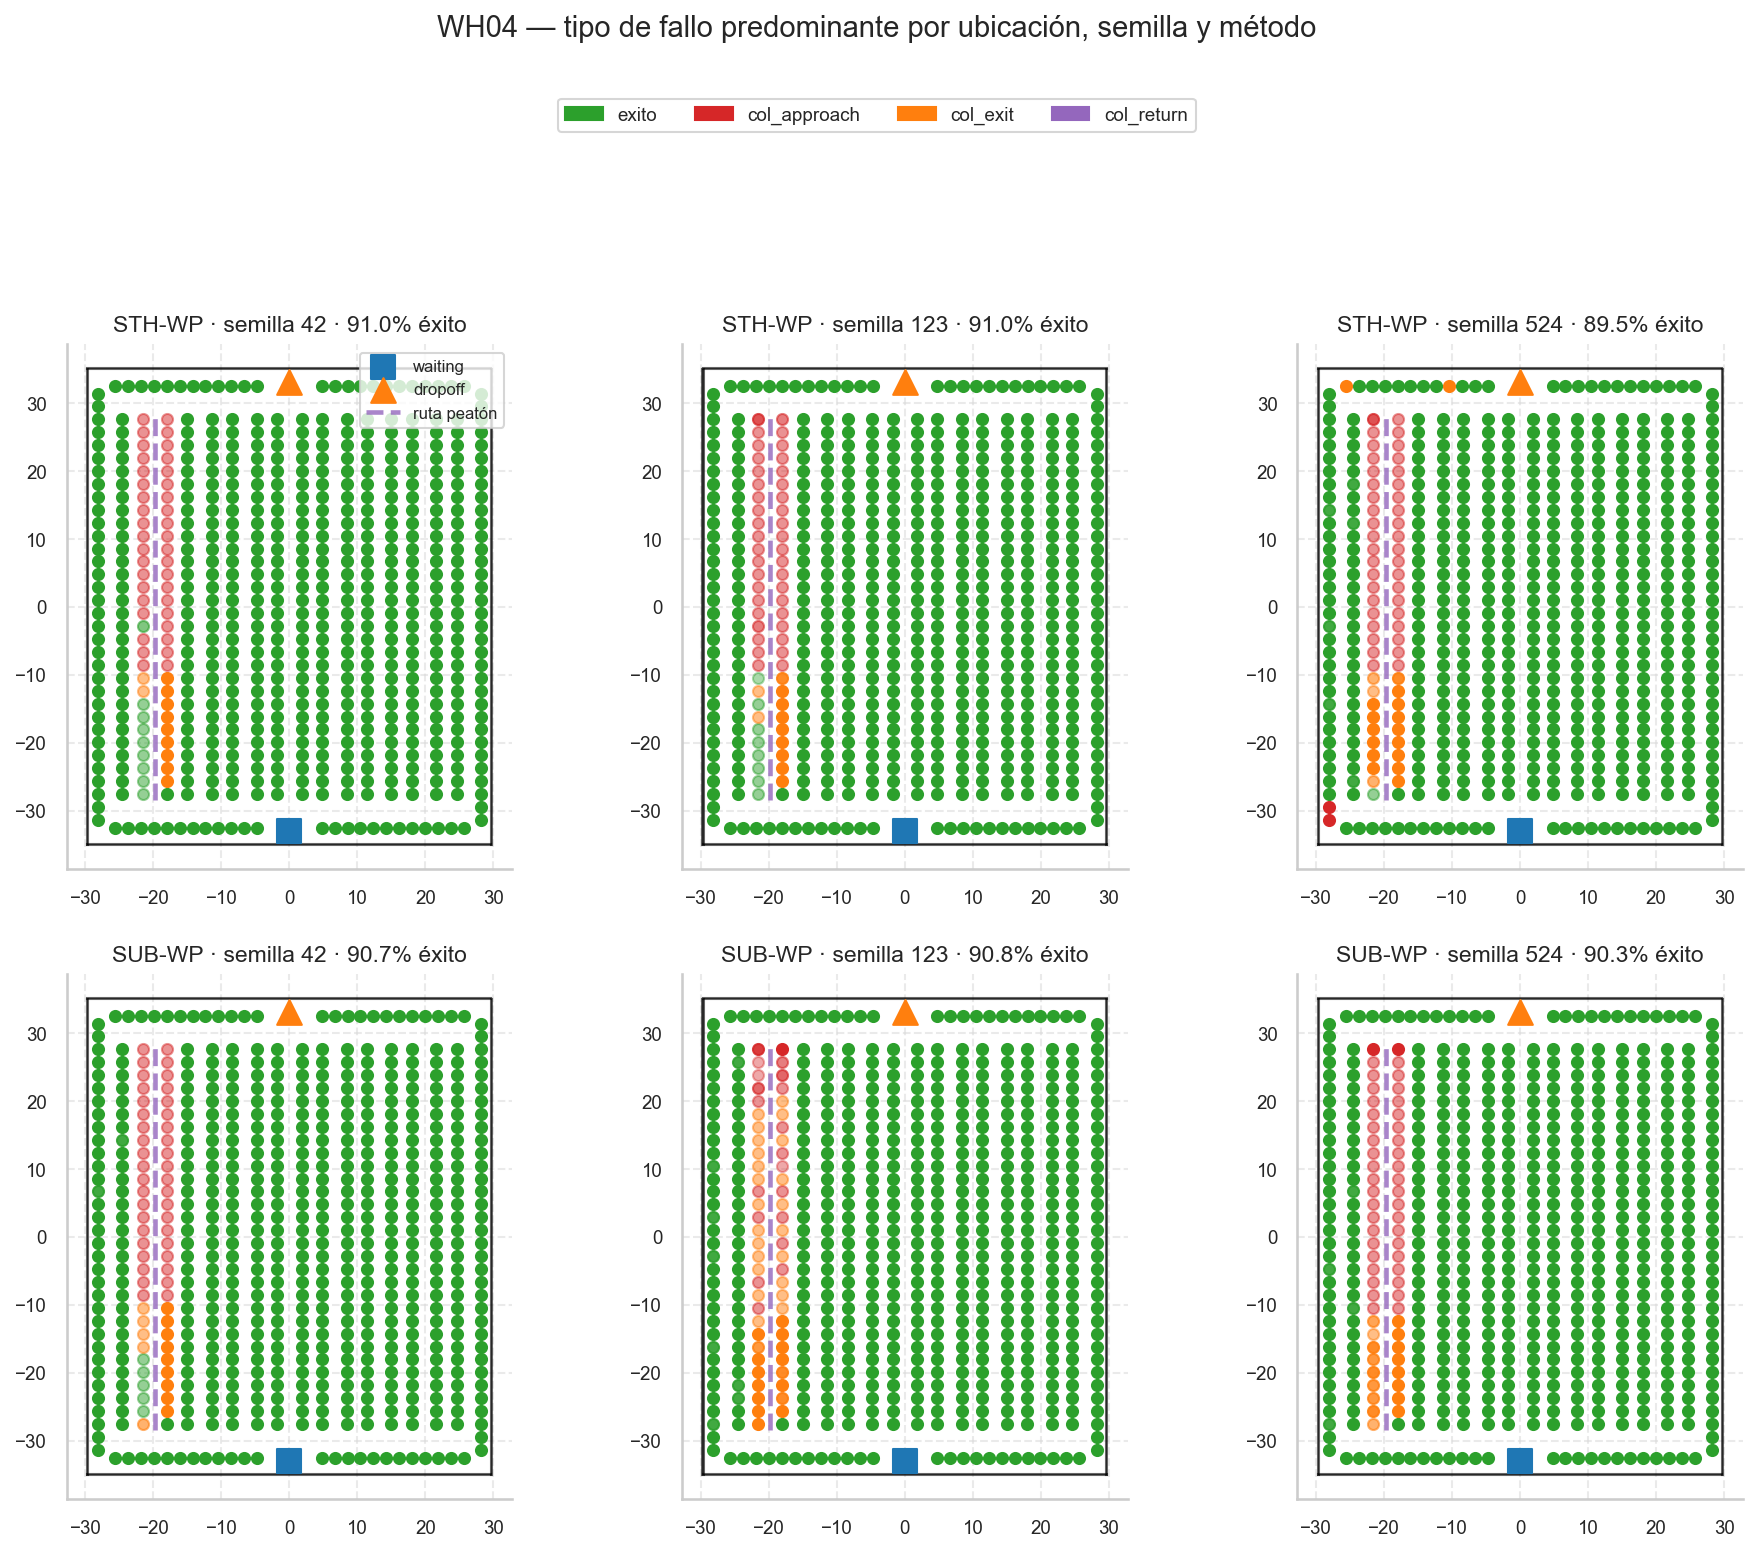

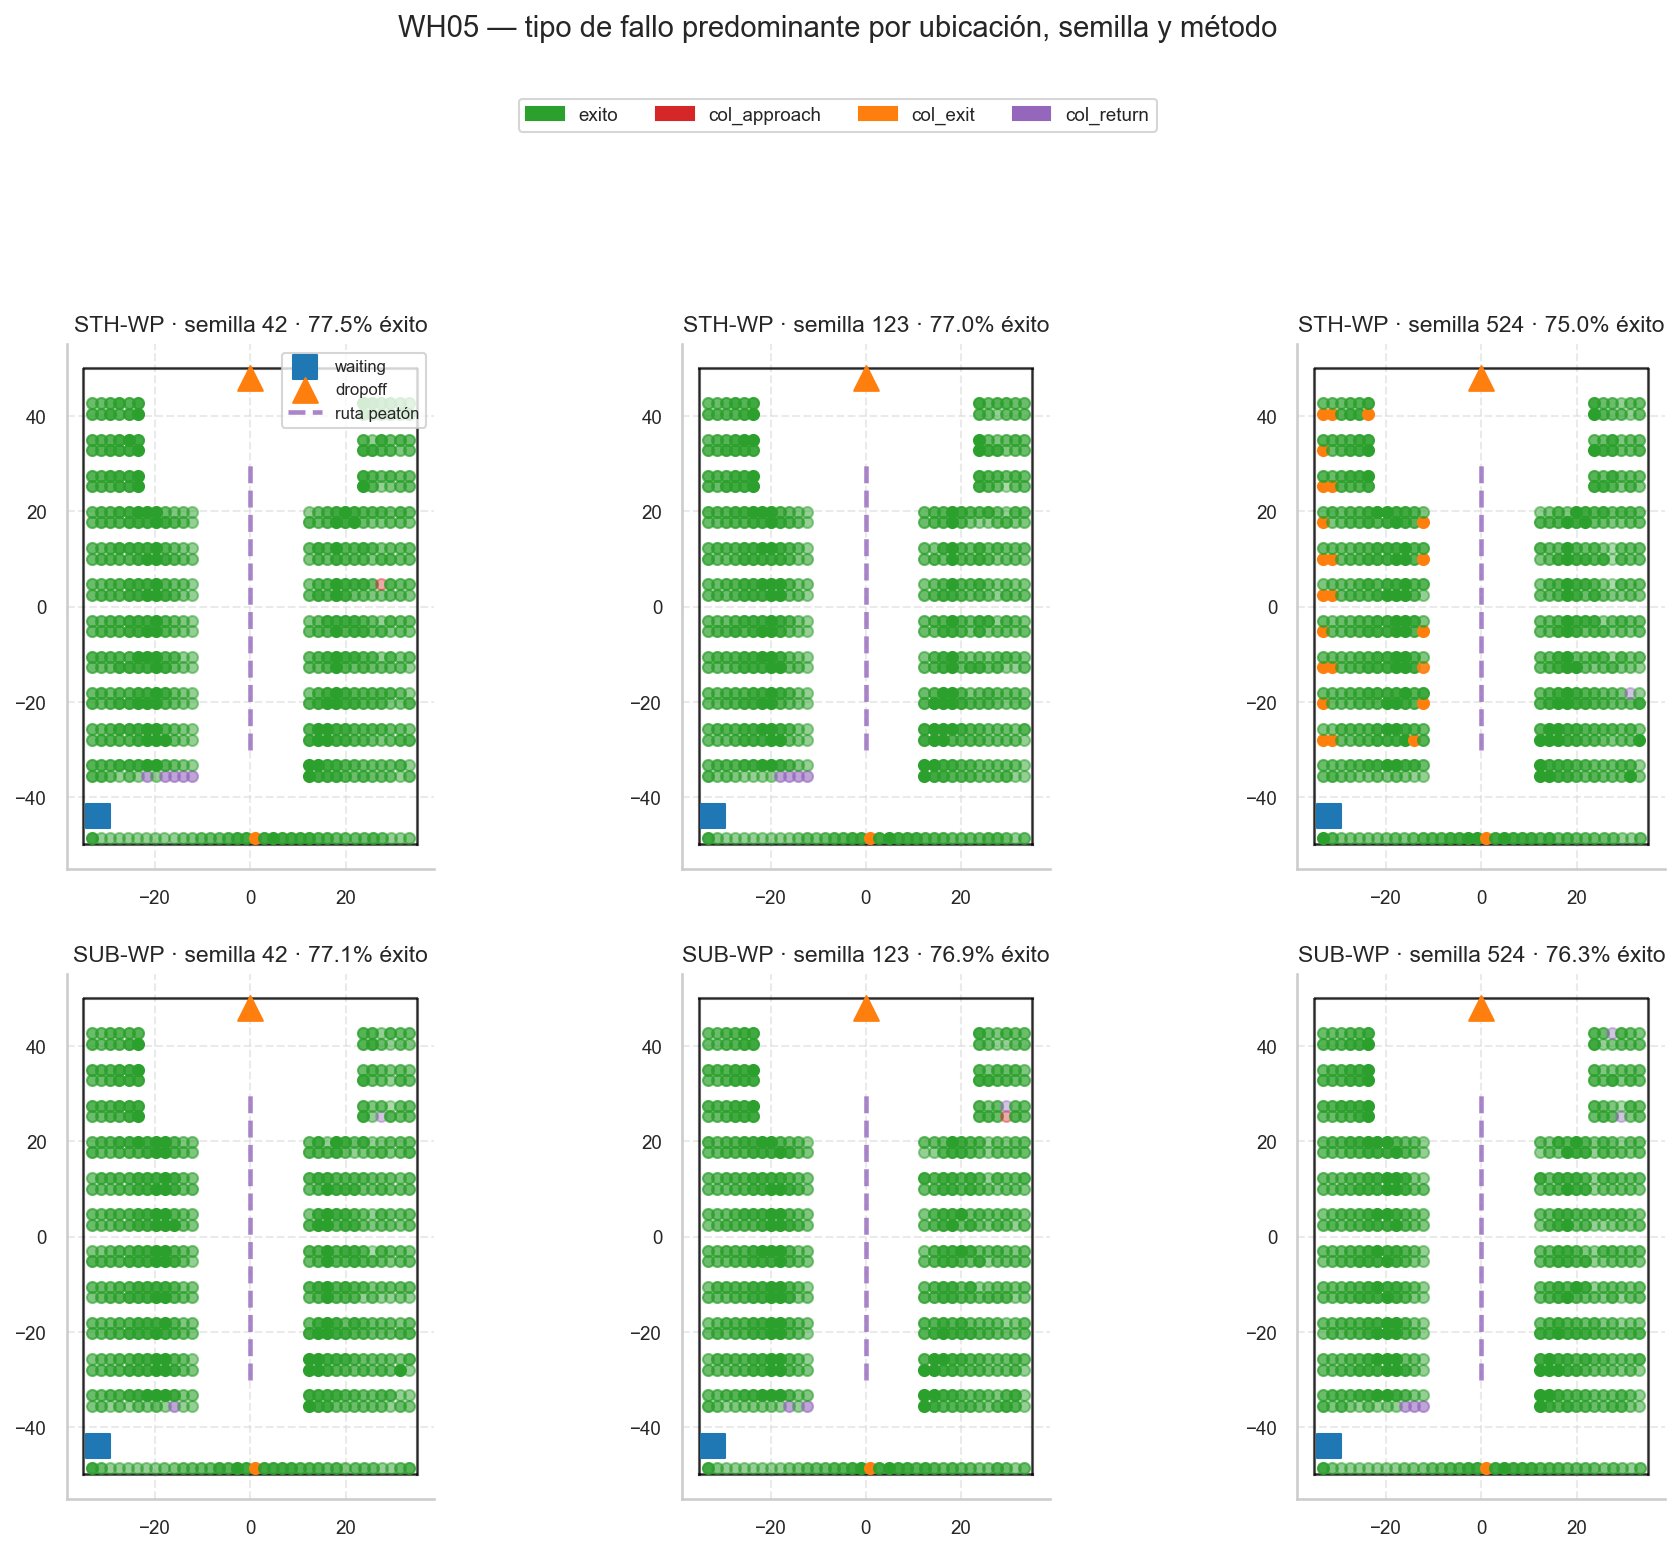

In [33]:
for wh in WH_ORDEN:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    seeds_orden = sorted(df2["seed"].unique(), key=lambda s: SEEDS.index(s) if s in SEEDS else 99)
    for i, metodo in enumerate(METODO_ORDEN):
        for j, seed in enumerate(seeds_orden):
            ax = axes[i, j]
            sub = df2[(df2["warehouse_id"] == wh) & (df2["metodo"] == metodo) & (df2["seed"] == seed)]
            if sub.empty:
                ax.set_title(f"{METODO_LABEL[metodo]} · semilla {seed} (sin datos)")
                ax.set_xticks([]); ax.set_yticks([])
                continue
            plot_almacen2_tipo_fallo(ax, wh, sub)
            tasa_media = sub["exito_bool"].mean() * 100
            ax.set_title(f"{METODO_LABEL[metodo]} · semilla {seed} · {tasa_media:.1f}% éxito")
    axes[0, 0].legend(loc="upper right", fontsize=8)
    leyenda_tipo = [mpatches.Patch(color=RESULTADO_COLOR[r], label=r) for r in RESULTADO_ORDEN if r in df2["resultado"].unique()]
    fig.legend(handles=leyenda_tipo, loc="upper center", ncol=len(leyenda_tipo), bbox_to_anchor=(0.5, 1.05))
    fig.suptitle(f"WH{wh} — tipo de fallo predominante por ubicación, semilla y método", y=1.1, fontsize=14)
    guardar(fig, f"15_tipo_fallo_seed_metodo_WH{wh}")
    plt.show()


## 11. Conclusiones — Fase 2

**Volumen:** 81.360 episodios completos (2 métodos × 3 seeds × 1.356 goals × 10 repeticiones), sin huecos.

- **Éxito global similar entre métodos, a diferencia de fase 1:** STH-WP 83.97% vs SUB-WP 84.32% (apenas 0.35pp de diferencia). En fase 1 (sin peatón) SUB-WP ganaba con claridad (100% vs 98.97%) — la ventaja de SUB-WP generalizando a almacenes nuevos casi desaparece en cuanto se introduce el peatón.
- **Coste de la evitación de peatón muy desigual por almacén** (sección 6): WH03 y WH04 apenas pierden 4-9pp respecto a fase 1, mientras que WH02 y WH05 pierden 20-23pp en ambos métodos. El peatón no es un coste fijo — interactúa con el layout concreto del almacén (pasillos más largos/estrechos en WH02 y WH05).
- **El gap de generalización cambia de signo entre métodos** (sección 7): STH-WP generaliza peor con peatón que en su propio entorno de entrenamiento (88.75% en WH01 → 83.97% en WH02-05, gap +4.78pp), mientras que SUB-WP generaliza ligeramente *mejor* que en WH01 (82.36% → 84.32%, gap -1.96pp). SUB-WP parece más robusto al trasladar la política de evitación de peatón a layouts nuevos.
- **El fallo depende genuinamente del cruce con el peatón, no es sistemático:** 1.136 de los 2.712 goals evaluados (42%) tienen un resultado mixto entre sus 10 repeticiones (ni 0% ni 100% de éxito) — confirma que la posición aleatoria del peatón en cada `reset()` es la que decide el desenlace en una fracción relevante de los casos, no un fallo determinista del goal.
- **`col_return` solo aparece en WH05** (sección 8, es el único almacén con un pasillo de peatón largo (60m) que atraviesa el tramo de retorno; en WH02-04 el desglose de fallos es exclusivamente `col_approach`/`col_exit`, igual que en fase 1.
